<a href="https://colab.research.google.com/github/EpiPandit/HPAI_Agent_hierarchical_models/blob/main/src_code/250924_psk_ABC_grid_fit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install scikit-optimize

In [1]:
import pandas as pd
import ab_sim as sim_mod
from scipy.special import gammaln
import numpy as np
import random
from scipy.special import gammaln
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import skewnorm
from skopt import gp_minimize
from skopt.space import Real
import warnings
warnings.filterwarnings("ignore")
import copy

In [2]:
merge_dwell = pd.DataFrame({
    'modelstate': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'min_duration': [60, 396, 60, 234, 18, 5, 30, 180, 100, 90, 200, 48, 1, 1, 2],
    'max_duration': [80, 458, 100, 264, 32, 30, 90, 200, 160, 180, 360, 66, 7, 7, 2]
})

merge_dwell['current_pen'] = [f"Pen{i}" for i in range(1, 16)]
transition_rules_dict = {
    "Pen1": "Pen2", "Pen2": "Pen3", "Pen3": "Pen4", "Pen4": "Pen5", "Pen5": "Pen15",
    "Pen6": "Pen8", "Pen7": "Pen10", "Pen8": "Pen9", "Pen9": "Pen12", "Pen10": "Pen11",
    "Pen11": "Pen12", "Pen12": "Pen13", "Pen13": "Pen14", "Pen14": "Pen15", "Pen15": None
}
merge_dwell['next_pen'] = merge_dwell['current_pen'].map(transition_rules_dict)

merge_dwell

,modelstate,min_duration,max_duration,current_pen,next_pen
0,1,60,80,Pen1,Pen2
1,2,396,458,Pen2,Pen3
2,3,60,100,Pen3,Pen4
3,4,234,264,Pen4,Pen5
4,5,18,32,Pen5,Pen15
5,6,5,30,Pen6,Pen8
6,7,30,90,Pen7,Pen10
7,8,180,200,Pen8,Pen9
8,9,100,160,Pen9,Pen12
9,10,90,180,Pen10,Pen11


In [3]:
burn_in_days = 365 * 10
ndays = 200
initial_infected_cows = {'d':20, 't':5, 'w':8, 'va':20}
num_cows_to_add_burn_in = {'d':900, 't':200, 'w':300, 'va':900}
incubation_period = 4

no_calves = ['Pen1', 'Pen2', 'Pen3', 'Pen4']

T_low, T_high = 0.01, 0.15
R_low, R_high = 0.04, 0.08
INCUBATION_LOW, INCUBATION_HIGH = 1, 6
SEED_LOW, SEED_HIGH = 1, 10

In [4]:
# For ABC simulation
ABC_N_SIMS = 1000         # number of prior draws (increase if you have time)
ABC_ACCEPT_TOP_K = ABC_N_SIMS/20    # keep top K closest simulated parameter sets

# For Grid search
grid_T = np.linspace(0.01, 0.15, 20)
grid_R = np.linspace(0.04, 0.08, 20)
grid_I = np.arange(INCUBATION_LOW, INCUBATION_HIGH+1, 1)
grid_Seed = np.arange(SEED_LOW, SEED_HIGH+1, 1)
# target outbreak (your observed curve)
target_curve = {'w':np.array([1,1,1,1,1,3,3,5,26,6,5,4,14,14,44,
                         2,16,1,1,2,2,1,1,1,1,1,1,1,1,1,1,1,1]), 
                't':np.array([2,15,3,2,10,4,5,3,3,2,1,2,3,6,1,1,
                         1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,
                         2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1]),
                'd':np.array([13,4,14,6,30,46,67,51,81,62,27,29,19,
                         17,42,25,19,10,14,12,10,4,3]),
               'va':np.array([1,1,1,6,6,6,19,22,30,39,59,17,10,10,6,16,20,13])}
ndays_target = {'w':len(target_curve['w']),
                't':len(target_curve['t']),
                'd':len(target_curve['d']),
               'va':len(target_curve['va'])}

In [5]:
def simulate_counts(burn_in_state, ndays, burn_in_days, init_infected, T, R,
                    incubation_period=4, pens_to_mask=None):
    # Convert farm → dict if needed
    if hasattr(burn_in_state, "cows"):
        burn_in_state = initial_cows

    res = sim_mod.run_main_simulation(burn_in_state,
                                 merge_dwell,
                                 ndays, burn_in_days,
                                 init_infected, T, R,
                                 incubation_period, pens_to_mask = no_calves)

    seir_df = res['seir_history']
    start_abs = burn_in_days
    if seir_df.empty:
        return np.zeros(ndays, dtype=int)

    # choose correct cow identifier column
    cow_col = None
    for candidate in ["cow_id", "id", "animal_id"]:
        if candidate in seir_df.columns:
            cow_col = candidate
            break
    if cow_col is None:
        raise KeyError(f"No cow ID column found in seir_history. Available: {list(seir_df.columns)}")

    # filter to first entry into Infectious
    df = seir_df[(seir_df['state'] == 'Infectious') &
                 (seir_df['absolute_day'] > start_abs) &
                 (seir_df['absolute_day'] <= start_abs + ndays)]
    if df.empty:
        return np.zeros(ndays, dtype=int)

    df_first = df.groupby(cow_col)['absolute_day'].min().reset_index()
    counts = df_first.groupby('absolute_day').size().reindex(
        range(start_abs+1, start_abs+ndays+1), fill_value=0).values

    return counts.astype(int)

In [6]:
# Simple DTW (O(n*m)) - fine for short sequences like 33 days
def dtw_distance(a, b):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0,0] = 0.0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(float(a[i-1]) - float(b[j-1]))
            D[i,j] = cost + min(D[i-1,j], D[i,j-1], D[i-1,j-1])
    return D[n,m]

# cross-correlation-based alignment: shift sim to align with obs, return minimal MAE across shifts
def crosscorr_alignment_distance(sim, obs, max_shift=None):
    # compute best shift of sim relative to obs to minimize MAE
    n = len(obs)
    if max_shift is None:
        max_shift = n // 2
    best_mae = np.mean(np.abs(sim - obs))  # zero shift baseline
    best_shift = 0
    for shift in range(-max_shift, max_shift+1):
        if shift == 0:
            continue
        # shift positive => sim delayed -> compare sim[shift:] with obs[:-shift]
        if shift > 0:
            s = sim[shift:]
            o = obs[:len(s)]
        else:
            s = sim[:len(sim)+shift]
            o = obs[-shift:len(obs)]
        if len(s) == 0:
            continue
        mae = np.mean(np.abs(s - o))
        if mae < best_mae:
            best_mae = mae
            best_shift = shift
    return best_mae, best_shift

# additional summary features for ML (for classifier)
def extract_features(curve):
    # raw stats + normalized peak/day + cumulative etc.
    curve = np.asarray(curve, dtype=float)
    total = curve.sum()
    peak = curve.max()
    peak_day = np.argmax(curve) + 1
    mean = curve.mean()
    std = curve.std()
    skew = 0.0
    if std > 0:
        skew = ((np.mean((curve-mean)**3)) / (std**3)) if std>0 else 0.0
    # normalized features
    feat = [total, peak, peak_day, mean, std, skew]
    return np.array(feat, dtype=float)

In [7]:
def plf(a,b):
    if len(a) != len(b):
        raise ValueError("inputs must have the same length.")
    epsilon = 1e-9
    log_fact = gammaln(b + 1)
    terms = a - b * np.log(a + epsilon) + log_fact
    weights = b + 1 #time varying weights proportional to b + 1 (avoids zero)
    return np.sum(weights * terms)/np.sum(weights)

In [8]:
cases = ["w", "t", "d", "va"]
case_inputs = {
    "w": {
        "merge_dwell": merge_dwell, 
        "num_cows_to_add_burn_in": num_cows_to_add_burn_in['w'],
        "burn_in_days": burn_in_days, 
    },
    "t": {
        "merge_dwell": merge_dwell, 
        "num_cows_to_add_burn_in": num_cows_to_add_burn_in['t'], 
        "burn_in_days": burn_in_days, 
    },
    "d": {
        "merge_dwell": merge_dwell, 
        "num_cows_to_add_burn_in": num_cows_to_add_burn_in['d'], 
        "burn_in_days": burn_in_days,
    },
    "va": {
        "merge_dwell": merge_dwell, 
        "num_cows_to_add_burn_in": num_cows_to_add_burn_in['va'], 
        "burn_in_days": burn_in_days,
    }
}
case_inputs['w']

{'merge_dwell':     modelstate  min_duration  max_duration current_pen next_pen
 0            1            60            80        Pen1     Pen2
 1            2           396           458        Pen2     Pen3
 2            3            60           100        Pen3     Pen4
 3            4           234           264        Pen4     Pen5
 4            5            18            32        Pen5    Pen15
 5            6             5            30        Pen6     Pen8
 6            7            30            90        Pen7    Pen10
 7            8           180           200        Pen8     Pen9
 8            9           100           160        Pen9    Pen12
 9           10            90           180       Pen10    Pen11
 10          11           200           360       Pen11    Pen12
 11          12            48            66       Pen12    Pen13
 12          13             1             7       Pen13    Pen14
 13          14             1             7       Pen14    Pen15
 14       

In [9]:
cases

['w', 't', 'd', 'va']

In [10]:
# Dictionaries to store results
burn_in_farms = {}
initial_cows_by_case = {}

# Loop over cases
for case in cases:
    inputs = case_inputs[case]
    
    # Create Farm instance for this case
    burn_in_farm = sim_mod.Farm(
        merge_dwell_df=inputs["merge_dwell"],
        initial_infected=0,
        transmission_rate=0,
        recovery_rate=0
    )
    
    # Add cows to Pen1 and Pen5
    for _ in range(inputs["num_cows_to_add_burn_in"]):
        burn_in_farm.add_cow("Pen1", lactation=0, state='Susceptible')
        burn_in_farm.add_cow("Pen5", lactation=0, state='Susceptible')
    
    # Run simulation
    burn_in_farm.run_simulation(inputs["burn_in_days"], 0, 1)
    
    # Get initial cows
    initial_cows = {cow.id: cow for cow in burn_in_farm.cows.values() if cow.alive}
    
    # Store results
    burn_in_farms[case] = burn_in_farm
    initial_cows_by_case[case] = initial_cows
    
    # Print result
    print(f"Case {case}: Burn-in finished with {len(initial_cows)} alive cows.")

Case w: Burn-in finished with 834 alive cows.
Case t: Burn-in finished with 685 alive cows.
Case d: Burn-in finished with 2715 alive cows.
Case va: Burn-in finished with 2588 alive cows.


In [11]:
len(initial_cows_by_case['va'])

2588

In [12]:
cases = ["w", "t", "d", "va"]
case_inputs = {
    "w": {
        "target_curve": target_curve['w'], 
        "ndays_target": ndays_target['w'], 
        "burn_in_farm": burn_in_farms['w'], 
        "burn_in_days": burn_in_days,  
        "no_calves": no_calves,        
    },
    "t": {
        "target_curve": target_curve['t'],
        "ndays_target": ndays_target['t'], 
        "burn_in_farm": burn_in_farms['t'], 
        "burn_in_days": burn_in_days, 
        "no_calves": no_calves,       
    },
    "d": {
        "target_curve": target_curve['d'], 
        "ndays_target": ndays_target['d'],  
        "burn_in_farm": burn_in_farms['d'],  
        "burn_in_days": burn_in_days,  
        "no_calves": no_calves,        
    },
    "va": {
        "target_curve": target_curve['va'], 
        "ndays_target": ndays_target['va'],  
        "burn_in_farm": burn_in_farms['va'],  
        "burn_in_days": burn_in_days,  
        "no_calves": no_calves,        
    }
}
case_inputs

{'w': {'target_curve': array([ 1,  1,  1,  1,  1,  3,  3,  5, 26,  6,  5,  4, 14, 14, 44,  2, 16,
          1,  1,  2,  2,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1]),
  'ndays_target': 33,
  'burn_in_farm': <ab_sim.Farm at 0x30d709f90>,
  'burn_in_days': 3650,
  'no_calves': ['Pen1', 'Pen2', 'Pen3', 'Pen4']},
 't': {'target_curve': array([ 2, 15,  3,  2, 10,  4,  5,  3,  3,  2,  1,  2,  3,  6,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  1]),
  'ndays_target': 53,
  'burn_in_farm': <ab_sim.Farm at 0x382fa7010>,
  'burn_in_days': 3650,
  'no_calves': ['Pen1', 'Pen2', 'Pen3', 'Pen4']},
 'd': {'target_curve': array([13,  4, 14,  6, 30, 46, 67, 51, 81, 62, 27, 29, 19, 17, 42, 25, 19,
         10, 14, 12, 10,  4,  3]),
  'ndays_target': 23,
  'burn_in_farm': <ab_sim.Farm at 0x3c0feeed0>,
  'burn_in_days': 3650,
  'no_calves': ['Pen1', 'Pen2', 'Pen3', '

In [14]:
cases

['w', 't', 'd', 'va']

In [13]:
pen_counts = burn_in_farms['va'].get_pen_counts_data()
pen_counts = pd.DataFrame(pen_counts)

In [14]:
pen_counts = pen_counts[pen_counts['day'] == 3650]
pen_counts

,day,pen,count,simulation_run
54735,3650,Pen1,169,None
54736,3650,Pen2,888,None
54737,3650,Pen3,105,None
54738,3650,Pen4,357,None
54739,3650,Pen5,14,None
54740,3650,Pen6,13,None
54741,3650,Pen7,92,None
54742,3650,Pen8,191,None
54743,3650,Pen9,150,None
54744,3650,Pen10,193,None


In [17]:
pen_counts.to_csv("pen_counts.csv", index = False)

In [18]:
# Dictionary to store abc_records for each case
abc_records_by_case = {case: [] for case in cases}

# Loop over cases
for case in cases:
    inputs = case_inputs[case]
    abc_records = []  # List of dicts: will hold T, R, incubation, seed, distance, sim_curve
    
    for i in tqdm(range(ABC_N_SIMS), desc=f"ABC Prior Sampling for case {case}"):
        # Sample priors
        T = float(np.random.uniform(T_low, T_high))
        R = float(np.random.uniform(R_low, R_high))
        incubation = int(np.random.randint(INCUBATION_LOW, INCUBATION_HIGH + 1))
        seed = int(np.random.randint(SEED_LOW, SEED_HIGH + 1))
        
        # Run sim with those sampled params
        sim_curve = simulate_counts(
            burn_in_state=burn_in_farms[case],  # Pass Farm object
            ndays=inputs["ndays_target"],
            burn_in_days=inputs["burn_in_days"],
            init_infected=seed,  # Integer for initial infected
            T=T,
            R=R,
            incubation_period=incubation,
            pens_to_mask=inputs["no_calves"]
        )
        
        # Distance: combine DTW, MAE, and CC
        d_dtw = dtw_distance(sim_curve, inputs["target_curve"])
        d_mae = np.mean(np.abs(sim_curve - inputs["target_curve"]))
        d_cc, best_shift = crosscorr_alignment_distance(
            sim_curve, inputs["target_curve"], max_shift=inputs["ndays_target"] // 2
        )
        distance = d_dtw + 5.0 * d_mae + 2.0 * d_cc
        
        abc_records.append({
            "T": T, 
            "R": R,
            "incubation": incubation, 
            "initial_seed": seed,
            "distance": distance, 
            "sim_curve": sim_curve
        })
    
    # Store results for this case
    abc_records_by_case[case] = abc_records
    
    # Save to CSV
    abc_df = pd.DataFrame(abc_records)
#     abc_df.to_csv(f'abc_records_{case}.csv', index=False)

ABC Prior Sampling for case va: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [03:51<00:00,  4.33it/s]


In [19]:
# Build DataFrames and accepted DataFrames for each case
abc_dfs = {}
accepted_dfs = {}

for case in cases:
    abc_records = abc_records_by_case[case]

    # Build DataFrame directly with sim_curves stored separately
    abc_df = pd.DataFrame(
        [{k: v for k, v in r.items() if k != "sim_curve"} for r in abc_records]
    )
    abc_df["sim_curve"] = [r["sim_curve"] for r in abc_records]
    abc_dfs[case] = abc_df

    # Sort by distance and keep top K
    accepted_df = abc_df.sort_values("distance", ascending=True).head(int(ABC_ACCEPT_TOP_K)).reset_index(drop=True)
    accepted_dfs[case] = accepted_df

    print(f"\nABC acceptance summary for case {case}:")
    print("  Kept top K =", len(accepted_df))
    print("  Accepted parameter ranges:")
    print("    T:   ", accepted_df["T"].min(), accepted_df["T"].max())
    print("    R:   ", accepted_df["R"].min(), accepted_df["R"].max())
    print("    incubation: ", accepted_df["incubation"].min(), accepted_df["incubation"].max())
    print("    initial_seed:", accepted_df["initial_seed"].min(), accepted_df["initial_seed"].max())


ABC acceptance summary for case w:
  Kept top K = 50
  Accepted parameter ranges:
    T:    0.010081763964426272 0.092838994757921
    R:    0.0407361599997328 0.07979081099054006
    incubation:  1 6
    initial_seed: 1 10

ABC acceptance summary for case t:
  Kept top K = 50
  Accepted parameter ranges:
    T:    0.010040219546283077 0.07060743119312442
    R:    0.042569893930800136 0.0798000831147807
    incubation:  1 6
    initial_seed: 1 10

ABC acceptance summary for case d:
  Kept top K = 50
  Accepted parameter ranges:
    T:    0.010226355016532927 0.06962439155766842
    R:    0.04038634222752913 0.07855850267304033
    incubation:  2 6
    initial_seed: 1 10

ABC acceptance summary for case va:
  Kept top K = 50
  Accepted parameter ranges:
    T:    0.010162101928626441 0.04315257005878702
    R:    0.04159518672259471 0.07969812612858067
    incubation:  3 6
    initial_seed: 1 10


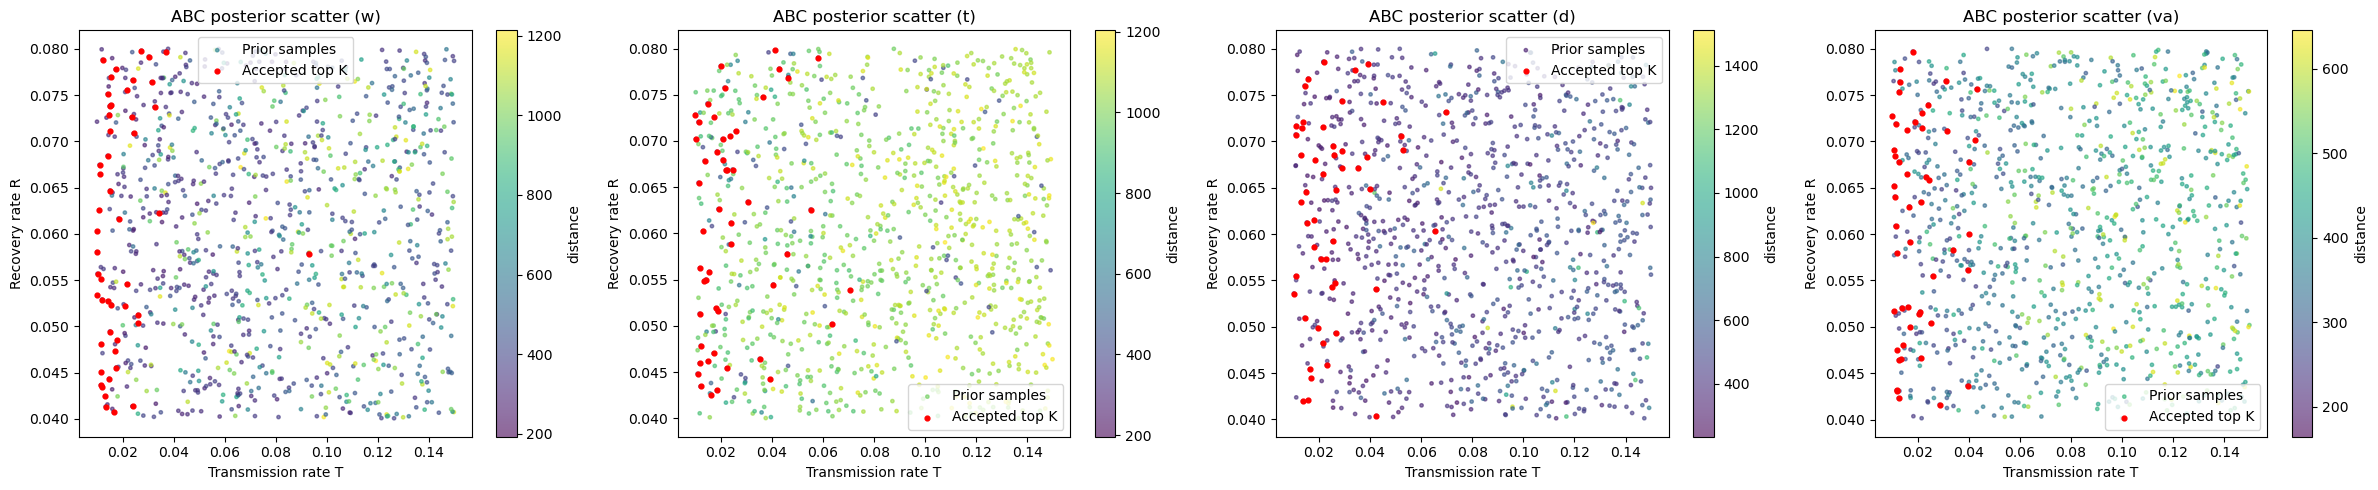

In [20]:
# Plot ABC posterior scatter (T vs R) for each case
fig, axes = plt.subplots(1, len(cases), figsize=(6 * len(cases), 5))

for i, case in enumerate(cases):
    ax = axes[i]
    abc_df = abc_dfs[case]

    # Use the pre-calculated accepted_df for this case
    accepted_df = accepted_dfs[case]

    # all prior samples, colored by distance
    scatter = ax.scatter(
        abc_df["T"], abc_df["R"],
        c=abc_df["distance"], cmap="viridis",
        s=6, alpha=0.6, label="Prior samples"
    )

    # accepted top K in red
    ax.scatter(
        accepted_df["T"], accepted_df["R"],
        c="red", s=12, label="Accepted top K"
    )

    fig.colorbar(scatter, ax=ax, label="distance")
    ax.set_xlabel("Transmission rate T")
    ax.set_ylabel("Recovery rate R")
    ax.set_title(f"ABC posterior scatter ({case})")
    ax.legend()

plt.tight_layout()
plt.show()
plt.close()

In [21]:
for i, case in enumerate(cases):
    accepted_dfs[case].to_csv(f'posterior_dm_{i+1}.csv', index = False)

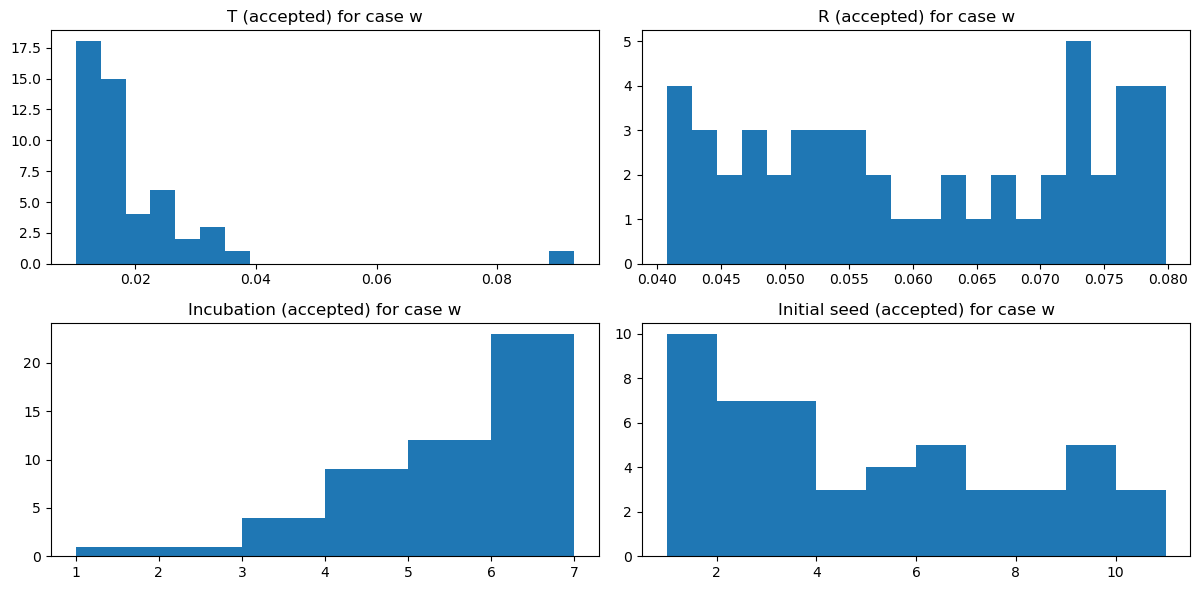

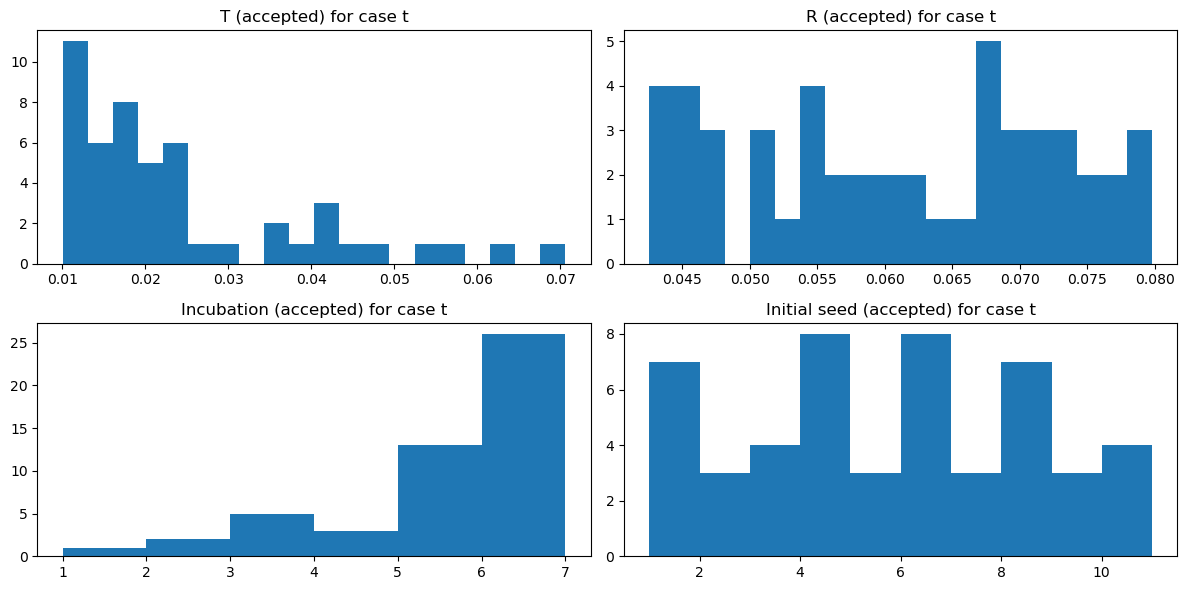

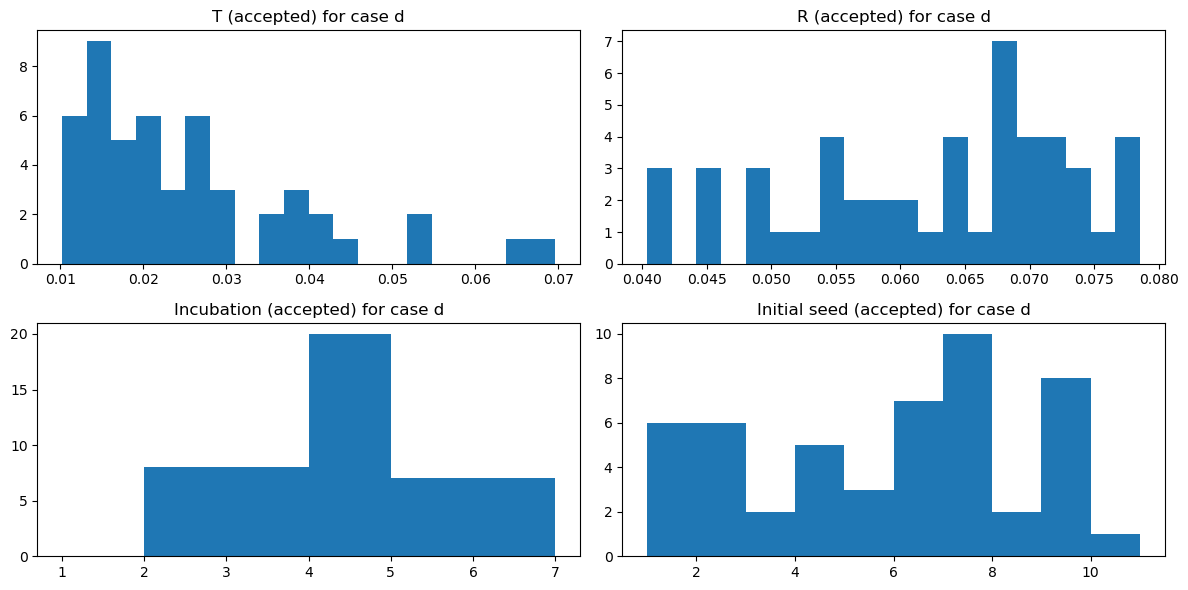

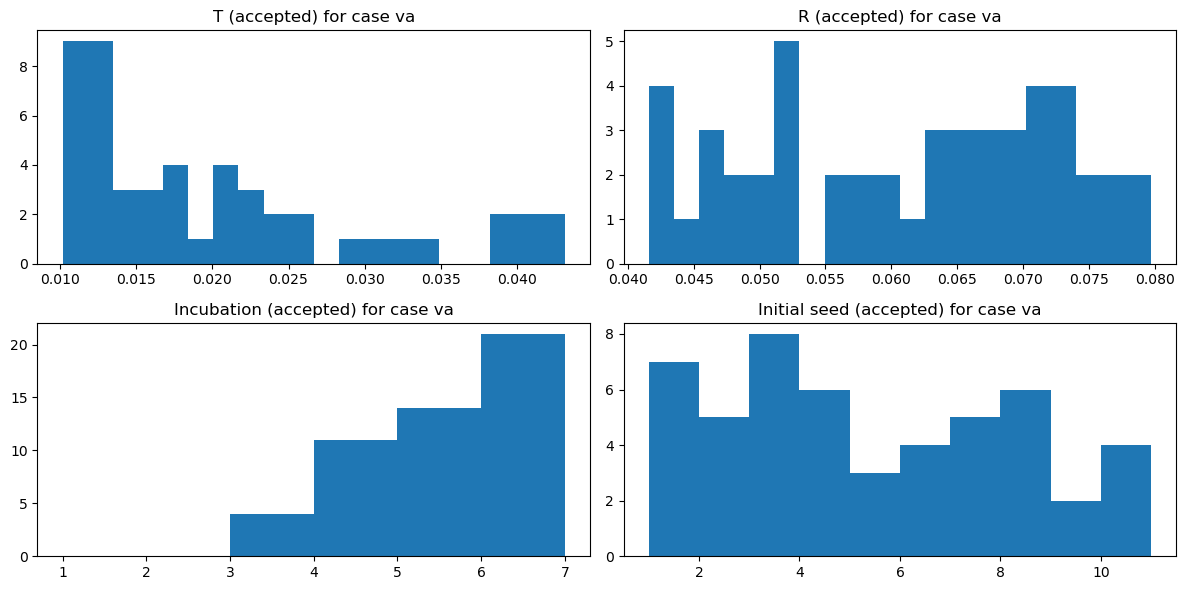

In [22]:
# Plot histograms of accepted parameters for each case
for case in cases:
    accepted_df = accepted_dfs[case]

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 2, 1)
    plt.hist(accepted_df['T'], bins=20)
    plt.title(f"T (accepted) for case {case}")

    plt.subplot(2, 2, 2)
    plt.hist(accepted_df['R'], bins=20)
    plt.title(f"R (accepted) for case {case}")

    plt.subplot(2, 2, 3)
    plt.hist(accepted_df['incubation'], bins=range(INCUBATION_LOW, INCUBATION_HIGH + 2))
    plt.title(f"Incubation (accepted) for case {case}")

    plt.subplot(2, 2, 4)
    plt.hist(accepted_df['initial_seed'], bins=range(SEED_LOW, SEED_HIGH + 2))
    plt.title(f"Initial seed (accepted) for case {case}")

    plt.tight_layout()
    plt.show()
    plt.close()


Running posterior simulations for case w...


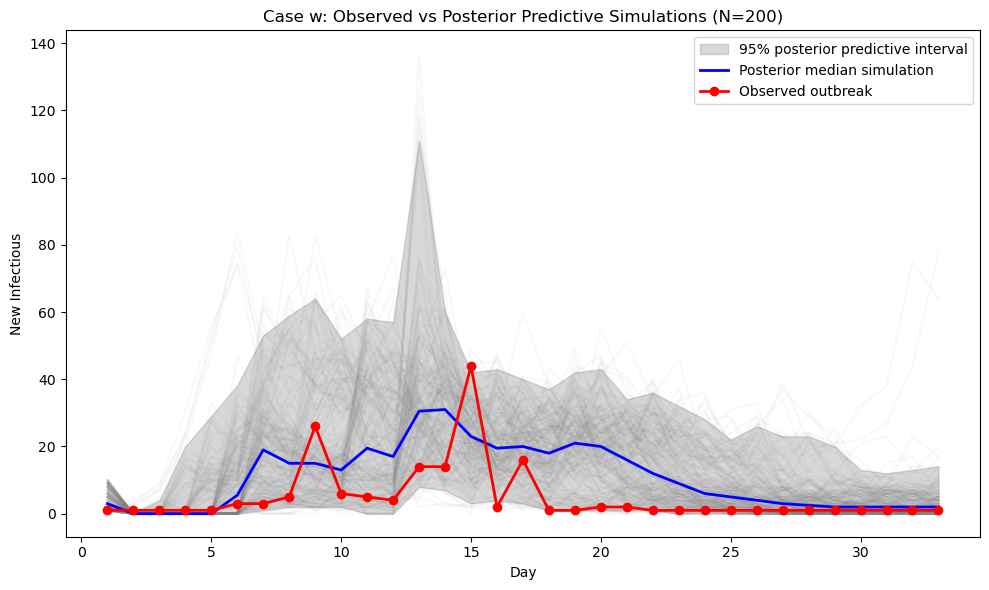


Running posterior simulations for case t...


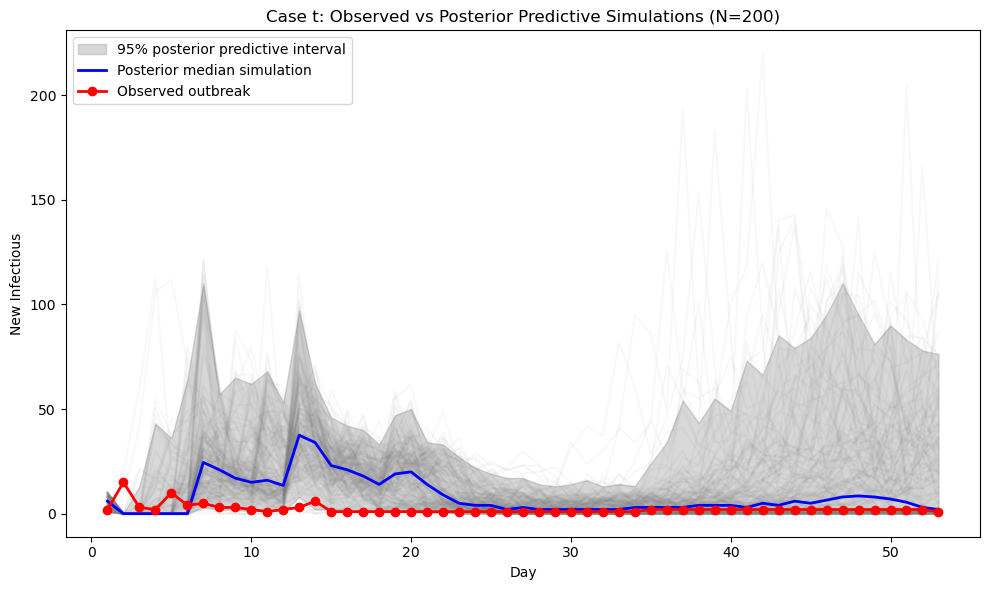


Running posterior simulations for case d...


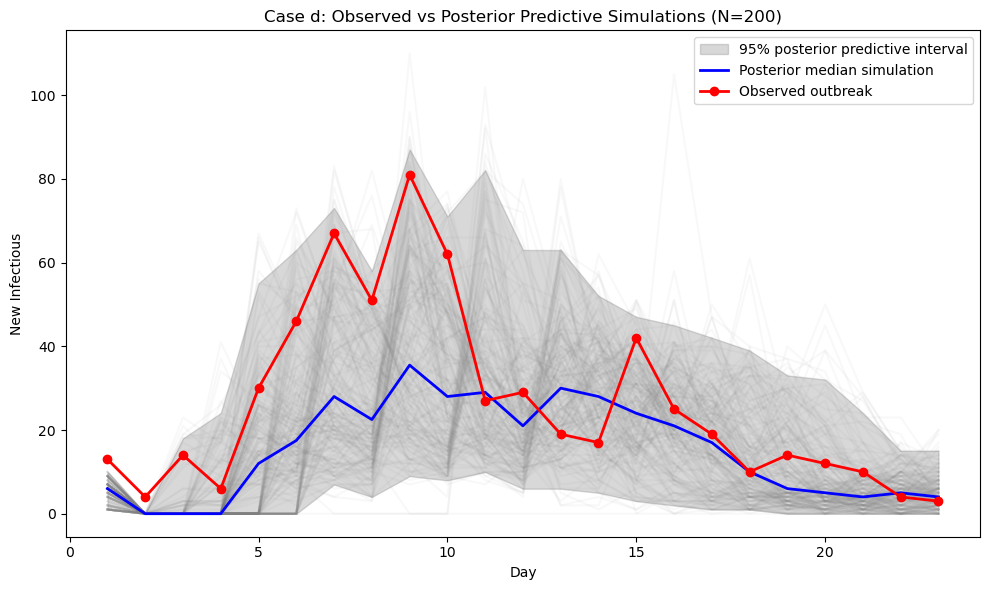


Running posterior simulations for case va...


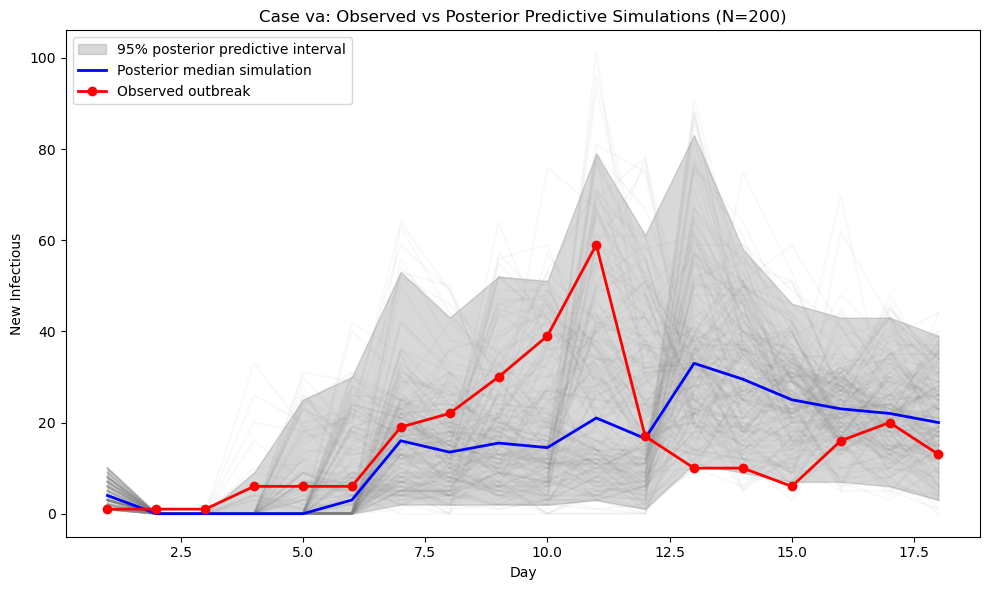

CPU times: user 3min 57s, sys: 5.24 s, total: 4min 2s
Wall time: 4min 2s


In [23]:
%%time
# -------------------------
# Run multiple simulations from posterior samples (fan plot version)
# -------------------------
N_post_sims = 200  # number of posterior simulations to run

for case in cases:
    print(f"\nRunning posterior simulations for case {case}...")
    accepted_df = accepted_dfs[case]
    ndays_target_case = ndays_target[case]
    burn_in_farm_case = burn_in_farms[case]
    target_curve_case = target_curve[case]

    # sample with replacement from accepted posterior dataframe
    posterior_df = accepted_df.sample(n=N_post_sims, replace=True).reset_index(drop=True)

    all_post_curves = []
    for _, row in posterior_df.iterrows():
        T = float(row['T'])
        R = float(row['R'])
        incubation = int(row['incubation'])
        seed = int(row['initial_seed'])
        sim_curve = simulate_counts(burn_in_farm_case, ndays_target_case, burn_in_days,
                                    seed, T, R,
                                    incubation, no_calves)
        all_post_curves.append(sim_curve)
    all_post_curves = np.array(all_post_curves)

    # Compute posterior predictive median and 95% envelope
    median_curve = np.median(all_post_curves, axis=0)
    low_curve = np.percentile(all_post_curves, 2.5, axis=0)
    high_curve = np.percentile(all_post_curves, 97.5, axis=0)

    # -------------------------
    # Plot observed vs posterior predictive distribution (fan plot)
    # -------------------------
    plt.figure(figsize=(10,6))
    days = np.arange(1, ndays_target_case+1)

    # fan plot: all individual posterior simulations (light gray, transparent)
    for curve in all_post_curves:
        plt.plot(days, curve, color='gray', alpha=0.05)

    # uncertainty band
    plt.fill_between(days, low_curve, high_curve, color='gray', alpha=0.3, label='95% posterior predictive interval')

    # posterior median
    plt.plot(days, median_curve, color='blue', lw=2, label='Posterior median simulation')

    # observed outbreak
    plt.plot(days, target_curve_case, 'o-', color='red', lw=2, label='Observed outbreak')

    plt.xlabel("Day")
    plt.ylabel("New Infectious")
    plt.title(f"Case {case}: Observed vs Posterior Predictive Simulations (N={N_post_sims})")
    plt.legend()
    plt.tight_layout()
    # plt.savefig(f'ABC_fan_plot_{case}.png', dpi =600)
    plt.show()
    plt.close()


Running posterior simulations for mean/CI plot for case w...


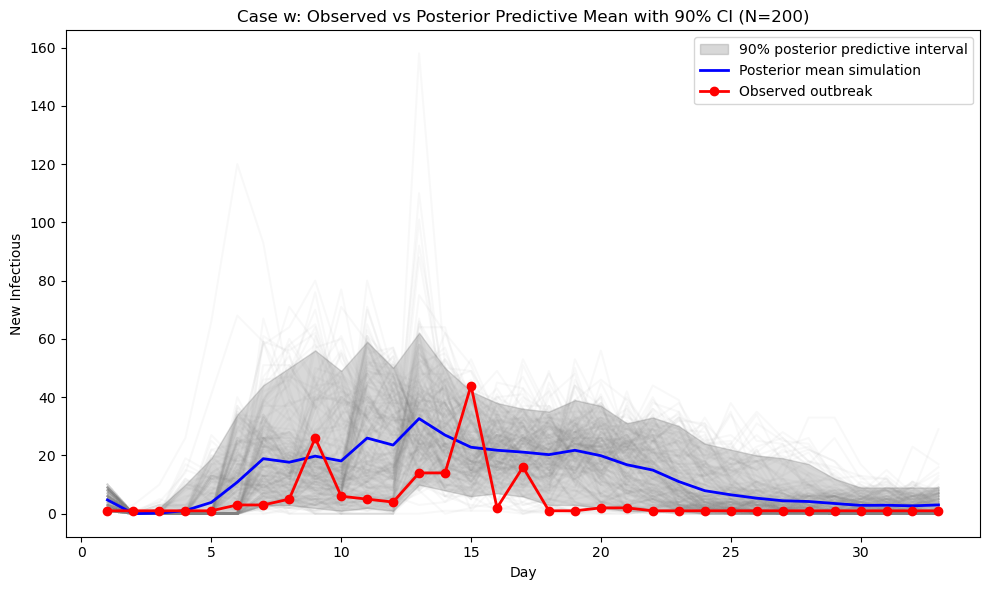


Running posterior simulations for mean/CI plot for case t...


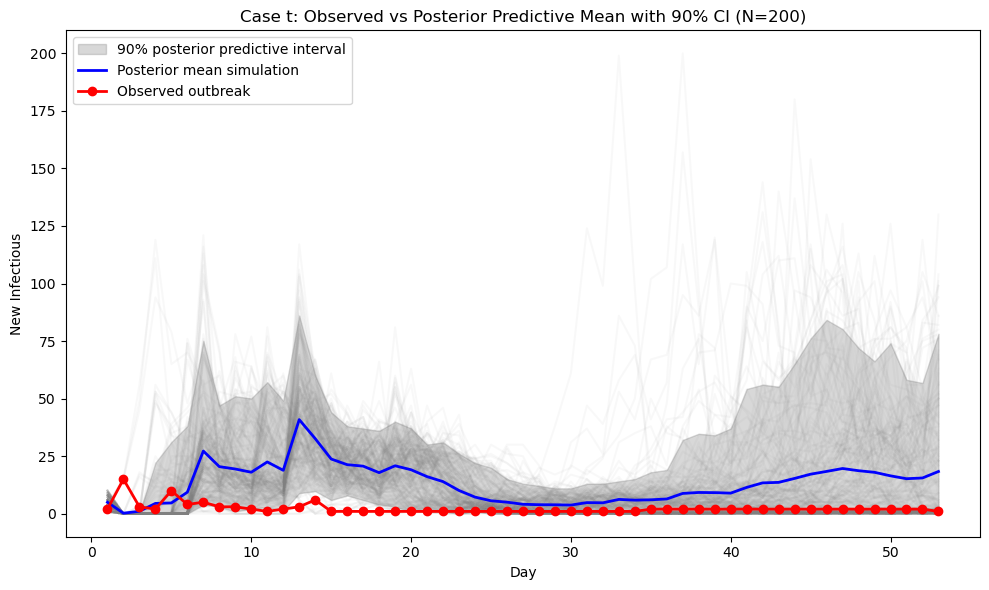


Running posterior simulations for mean/CI plot for case d...


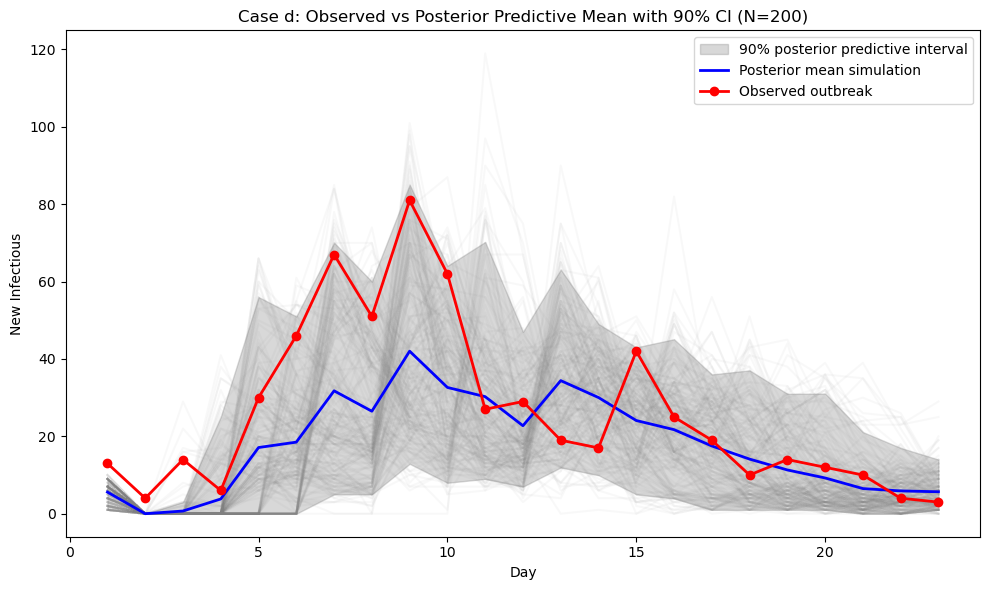


Running posterior simulations for mean/CI plot for case va...


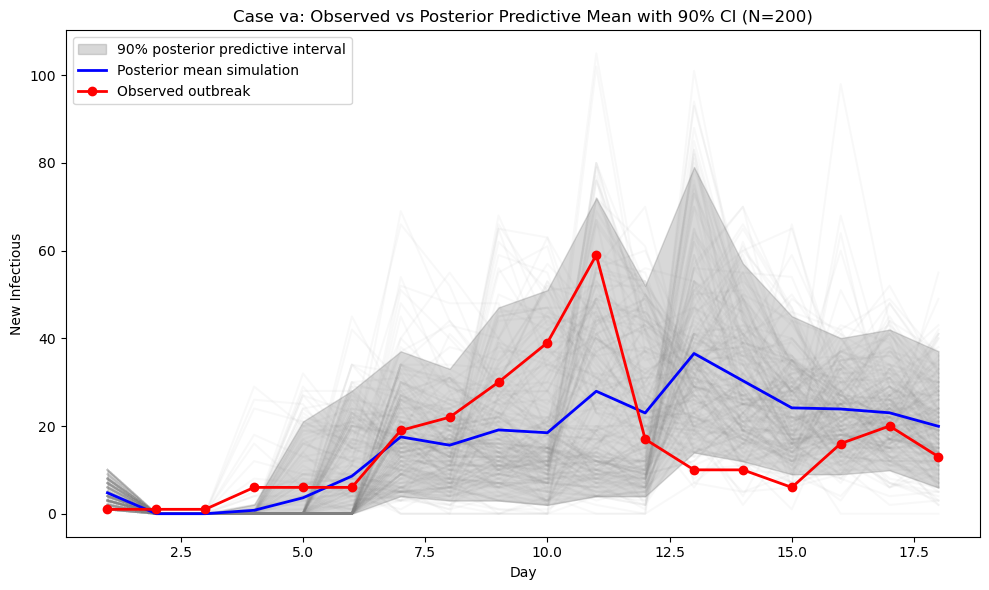

In [24]:
# Assume simulate_counts, burn_in_farm, ndays_target, burn_in_days, no_calves,
# accepted_df, and target_curve are defined elsewhere

N_post_sims = 200  # number of posterior simulations to run
mean_curves_combined = {}
for case in cases:
    print(f"\nRunning posterior simulations for mean/CI plot for case {case}...")
    accepted_df = accepted_dfs[case]
    ndays_target_case = ndays_target[case]
    burn_in_farm_case = burn_in_farms[case]
    target_curve_case = target_curve[case]

    # sample with replacement from accepted posterior dataframe
    posterior_df = accepted_df.sample(n=N_post_sims, replace=True).reset_index(drop=True)

    all_post_curves = []
    for _, row in posterior_df.iterrows():
        T = float(row['T'])
        R = float(row['R'])
        incubation = int(row['incubation'])
        seed = int(row['initial_seed'])
        sim_curve = simulate_counts(burn_in_farm_case, ndays_target_case, burn_in_days,
                                    seed, T, R,
                                    incubation, no_calves)
        all_post_curves.append(sim_curve)
    all_post_curves = np.array(all_post_curves)

    # Compute posterior predictive mean and 90% confidence interval
    mean_curve = np.mean(all_post_curves, axis=0)
    low_curve = np.percentile(all_post_curves, 5, axis=0)
    high_curve = np.percentile(all_post_curves, 95, axis=0)
    mean_curves_combined[case] = mean_curve
    # -------------------------
    # Plot observed vs posterior predictive distribution (mean with 90% CI)
    # -------------------------
    plt.figure(figsize=(10,6))
    days = np.arange(1, ndays_target_case+1)
    
    for curve in all_post_curves:
        plt.plot(days, curve, color='gray', alpha=0.05)   

    # uncertainty band
    plt.fill_between(days, low_curve, high_curve, color='gray', alpha=0.3, label='90% posterior predictive interval')

    # posterior mean
    plt.plot(days, mean_curve, color='blue', lw=2, label='Posterior mean simulation')

    # observed outbreak
    plt.plot(days, target_curve_case, 'o-', color='red', lw=2, label='Observed outbreak')

    plt.xlabel("Day")
    plt.ylabel("New Infectious")
    plt.title(f"Case {case}: Observed vs Posterior Predictive Mean with 90% CI (N={N_post_sims})")
    plt.legend()
    plt.tight_layout()
    # plt.savefig(f'ABC_mean_CI_plot_{case}.png', dpi=600)
    plt.show()
    plt.close()

In [25]:
%%time
print(f"\nRunning prior sampling using poisson loss function with {ABC_N_SIMS} simulations")

abc_plf_by_case = {case: [] for case in cases}

for case in cases:
    inputs = case_inputs[case]
    abc_plf = []

    for i in range(ABC_N_SIMS):
        # sample priors
        T = float(np.random.uniform(T_low, T_high))
        R = float(np.random.uniform(R_low, R_high))
        incubation = int(np.random.randint(INCUBATION_LOW, INCUBATION_HIGH + 1))
        seed = int(np.random.randint(SEED_LOW, SEED_HIGH + 1))

        # run sim with those sampled params
        sim_curve = simulate_counts(
            inputs["burn_in_farm"], inputs["ndays_target"], burn_in_days,
            seed, T, R, incubation, no_calves
        )

        plf_apply = plf(sim_curve, inputs["target_curve"])

        abc_plf.append({
            "T": T, "R": R,
            "incubation": incubation, "initial_seed": seed,
            "poisson_loss": plf_apply, "sim_curve": sim_curve
        })
    abc_plf_by_case[case] = abc_plf


Running prior sampling using poisson loss function with 1000 simulations
CPU times: user 19min 28s, sys: 28 s, total: 19min 56s
Wall time: 19min 56s


In [26]:
# repeat for poisson loss function
df_plf_by_case = {}
accepted_plf_by_case = {}

for case in cases:
    abc_plf = abc_plf_by_case[case]

    df_plf = pd.DataFrame(
        [{k: v for k, v in r.items() if k != "sim_curve"} for r in abc_plf]
    )
    df_plf["sim_curve"] = [r["sim_curve"] for r in abc_plf]
    df_plf_by_case[case] = df_plf

    # Sort by distance and keep top K
    accepted_plf = df_plf.sort_values("poisson_loss", ascending=True).head(int(ABC_ACCEPT_TOP_K)).reset_index(drop=True)
    accepted_plf_by_case[case] = accepted_plf

    print(f"\nABC acceptance summary (Poisson loss function) for case {case}:")
    print("  Kept top K =", len(accepted_plf))
    print("  Accepted parameter ranges:")
    print("    T:   ", accepted_plf["T"].min(), accepted_plf["T"].max())
    print("    R:   ", accepted_plf["R"].min(), accepted_plf["R"].max())
    print("    incubation: ", accepted_plf["incubation"].min(), accepted_plf["incubation"].max())
    print("    initial_seed:", accepted_plf["initial_seed"].min(), accepted_plf["initial_seed"].max())


ABC acceptance summary (Poisson loss function) for case w:
  Kept top K = 50
  Accepted parameter ranges:
    T:    0.010778909399357935 0.10183158754723025
    R:    0.04193264207966395 0.07638308444459642
    incubation:  3 6
    initial_seed: 1 10

ABC acceptance summary (Poisson loss function) for case t:
  Kept top K = 50
  Accepted parameter ranges:
    T:    0.01002505263034672 0.12354922816231806
    R:    0.0414777011063975 0.07944543258858687
    incubation:  1 1
    initial_seed: 1 10

ABC acceptance summary (Poisson loss function) for case d:
  Kept top K = 50
  Accepted parameter ranges:
    T:    0.010911194039044947 0.07429019606442563
    R:    0.04008025012159264 0.07988236473450844
    incubation:  1 4
    initial_seed: 1 10

ABC acceptance summary (Poisson loss function) for case va:
  Kept top K = 50
  Accepted parameter ranges:
    T:    0.010617449828012422 0.07069758383675406
    R:    0.04025308232362722 0.07992739276430735
    incubation:  1 5
    initial_seed

In [27]:
accepted_plf_by_case

{'w':            T         R  incubation  initial_seed  poisson_loss  \
 0   0.017925  0.069569           3            10      7.562970   
 1   0.016246  0.051014           3             1      7.682872   
 2   0.022308  0.048058           3             5      7.683575   
 3   0.010779  0.065287           4             5      7.730327   
 4   0.017926  0.075689           3             1      7.864058   
 5   0.015455  0.044104           3             4      8.036089   
 6   0.019180  0.045750           3             2      8.114842   
 7   0.060215  0.073817           5             5      8.196541   
 8   0.013668  0.043499           3             6      8.277912   
 9   0.019625  0.052928           4             6      8.347388   
 10  0.016014  0.064498           3             2      8.365904   
 11  0.021557  0.064281           4             1      8.476746   
 12  0.032070  0.049258           4            10      8.517481   
 13  0.020944  0.076383           4             8      8.

In [28]:
for i, case in enumerate(cases):
    accepted_plf_by_case[case].to_csv(f'posterior_plf_{i+1}.csv', index = False)


Running posterior simulations (Poisson Loss Function) for mean/CI plot for case w...


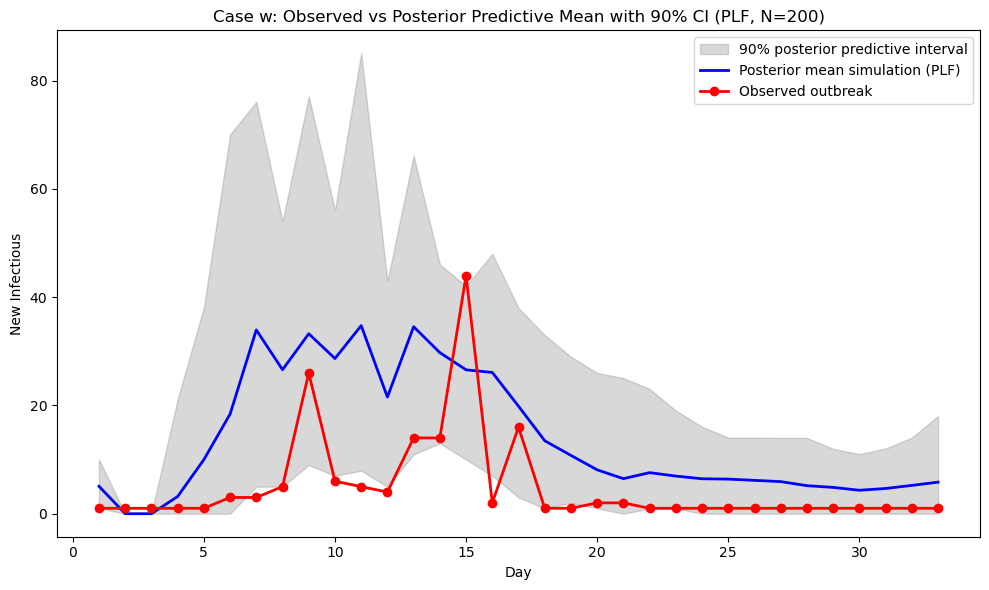


Running posterior simulations (Poisson Loss Function) for mean/CI plot for case t...


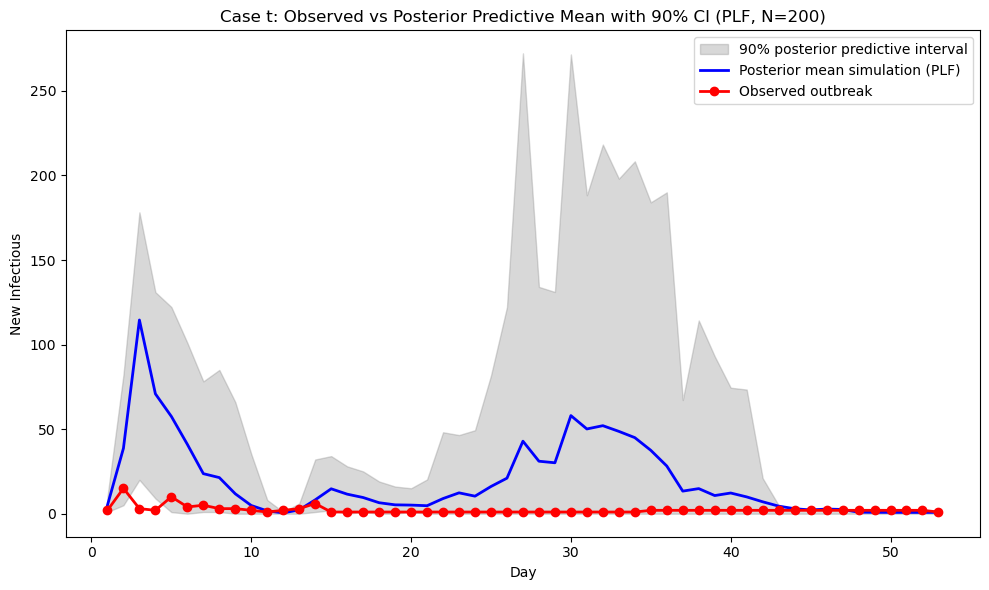


Running posterior simulations (Poisson Loss Function) for mean/CI plot for case d...


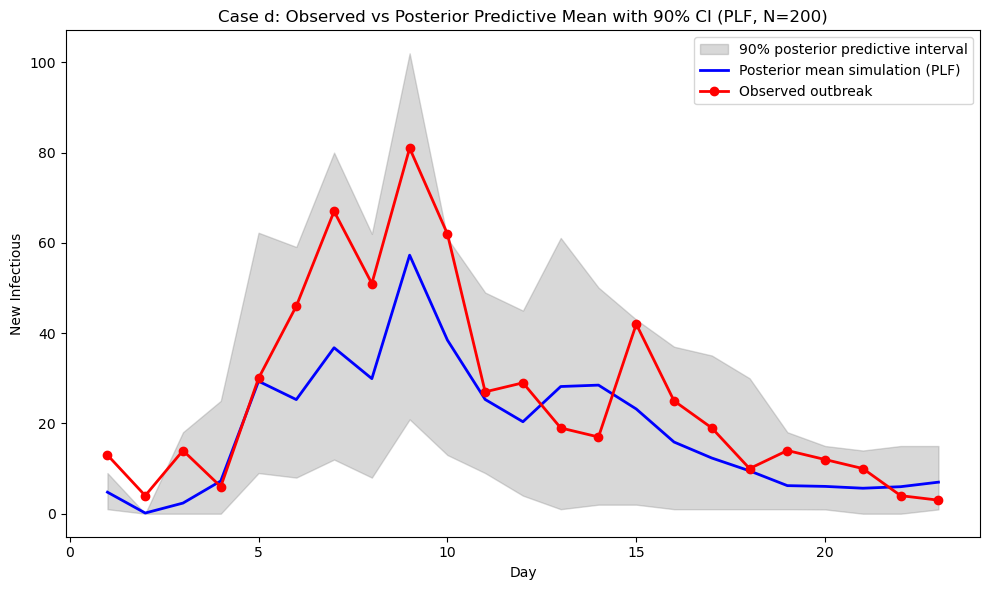


Running posterior simulations (Poisson Loss Function) for mean/CI plot for case va...


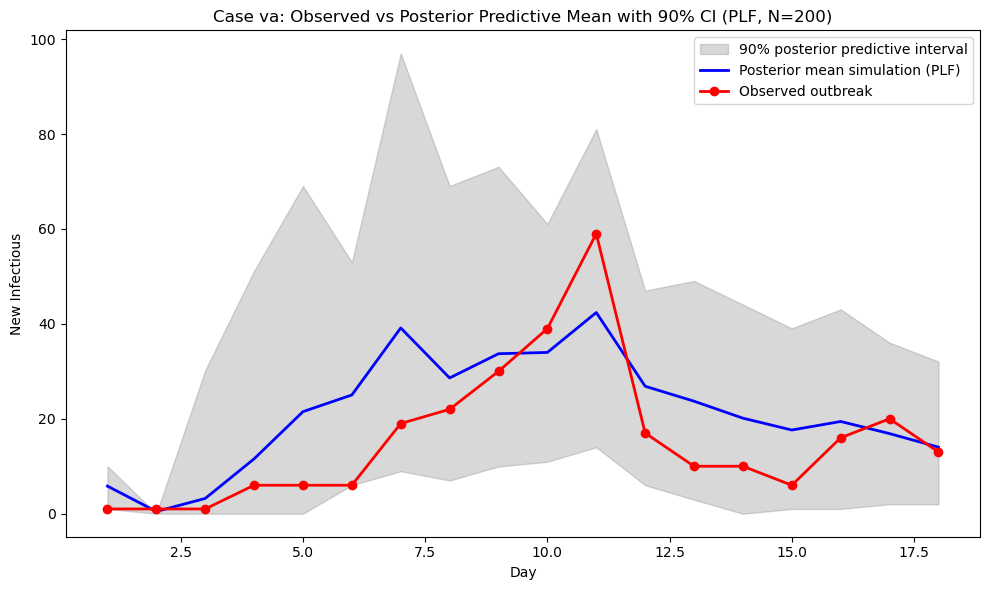

In [29]:
# Assume simulate_counts, burn_in_farm, ndays_target, burn_in_days, no_calves,
# accepted_df, and target_curve are defined elsewhere

N_post_sims = 200  # number of posterior simulations to run

# Dictionary to store mean curves for PLF
mean_curves_plf = {}

for case in cases:
    print(f"\nRunning posterior simulations (Poisson Loss Function) for mean/CI plot for case {case}...")
    accepted_plf = accepted_plf_by_case[case]
    ndays_target_case = ndays_target[case]
    burn_in_farm_case = burn_in_farms[case]
    target_curve_case = target_curve[case]


    # sample with replacement from accepted posterior dataframe
    posterior_plf = accepted_plf.sample(n=N_post_sims, replace=True).reset_index(drop=True)

    all_post_curves_plf = []
    for _, row in posterior_plf.iterrows():
        T = float(row['T'])
        R = float(row['R'])
        incubation = int(row['incubation'])
        seed = int(row['initial_seed'])
        sim_curve = simulate_counts(burn_in_farm_case, ndays_target_case, burn_in_days,
                                    seed, T, R,
                                    incubation, no_calves)
        all_post_curves_plf.append(sim_curve)
    all_post_curves_plf = np.array(all_post_curves_plf)

    # Compute posterior predictive mean and 90% confidence interval
    mean_curve_plf = np.mean(all_post_curves_plf, axis=0)
    low_curve_plf = np.percentile(all_post_curves_plf, 5, axis=0)
    high_curve_plf = np.percentile(all_post_curves_plf, 95, axis=0)

    # Store the mean curve for this case (PLF)
    mean_curves_plf[case] = mean_curve_plf

    # -------------------------
    # Plot observed vs posterior predictive distribution (mean with 90% CI)
    # -------------------------
    plt.figure(figsize=(10,6))
    days = np.arange(1, ndays_target_case+1)

    # uncertainty band
    plt.fill_between(days, low_curve_plf, high_curve_plf, color='gray', alpha=0.3, label='90% posterior predictive interval')

    # posterior mean
    plt.plot(days, mean_curve_plf, color='blue', lw=2, label='Posterior mean simulation (PLF)')

    # observed outbreak
    plt.plot(days, target_curve_case, 'o-', color='red', lw=2, label='Observed outbreak')

    plt.xlabel("Day")
    plt.ylabel("New Infectious")
    plt.title(f"Case {case}: Observed vs Posterior Predictive Mean with 90% CI (PLF, N={N_post_sims})")
    plt.legend()
    plt.tight_layout()
    # plt.savefig(f'ABC_mean_CI_plot_PLF_{case}.png', dpi=600)
    plt.show()
    plt.close()

In [30]:
mean_curves_combined

{'w': array([4.7300e+00, 2.0000e-02, 2.1000e-01, 1.0850e+00, 3.8750e+00,
        1.0835e+01, 1.8875e+01, 1.7670e+01, 1.9745e+01, 1.8110e+01,
        2.5960e+01, 2.3555e+01, 3.2635e+01, 2.6985e+01, 2.2815e+01,
        2.1780e+01, 2.1130e+01, 2.0270e+01, 2.1765e+01, 1.9915e+01,
        1.6810e+01, 1.4970e+01, 1.1035e+01, 7.9000e+00, 6.4900e+00,
        5.3300e+00, 4.4450e+00, 4.1900e+00, 3.5050e+00, 2.8600e+00,
        2.9000e+00, 2.7000e+00, 3.0100e+00]),
 't': array([ 4.98 ,  0.225,  1.06 ,  4.47 ,  4.67 ,  9.35 , 27.225, 20.45 ,
        19.415, 18.015, 22.495, 18.855, 40.885, 32.625, 23.76 , 21.3  ,
        20.665, 17.83 , 20.825, 19.095, 16.105, 13.945, 10.085,  7.215,
         5.61 ,  5.02 ,  4.1  ,  3.91 ,  3.87 ,  3.75 ,  4.82 ,  4.73 ,
         6.21 ,  5.885,  6.035,  6.405,  8.81 ,  9.225,  9.15 ,  8.94 ,
        11.425, 13.39 , 13.61 , 15.335, 17.17 , 18.37 , 19.64 , 18.68 ,
        17.985, 16.45 , 15.205, 15.52 , 18.335]),
 'd': array([ 5.585,  0.   ,  0.695,  3.81 , 17.105, 1

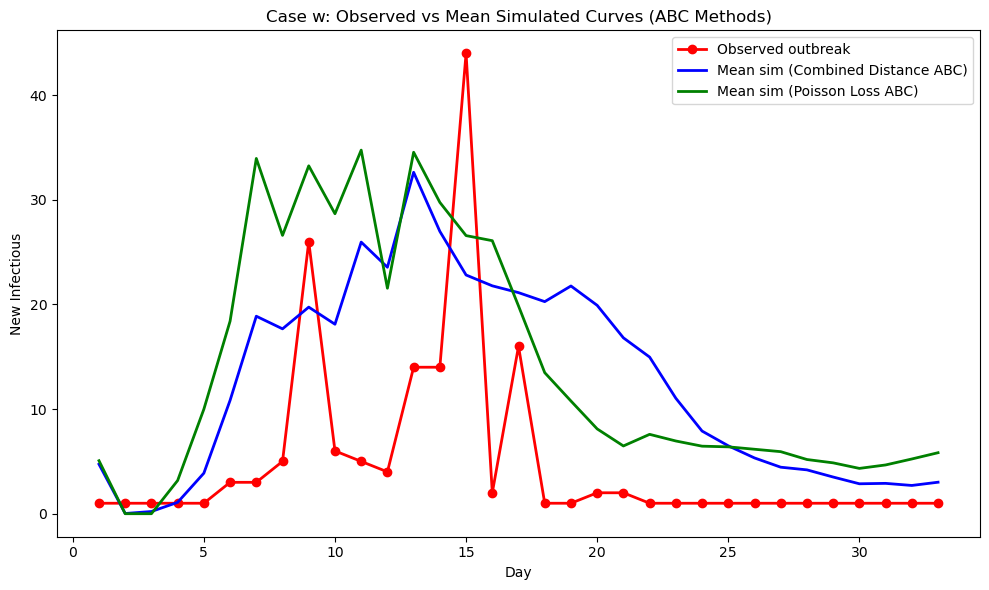

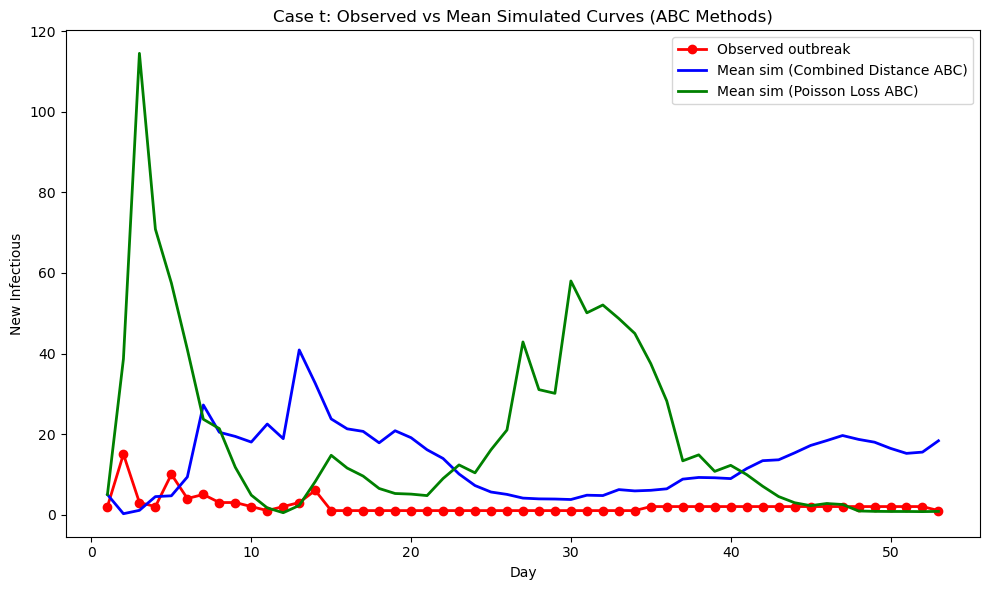

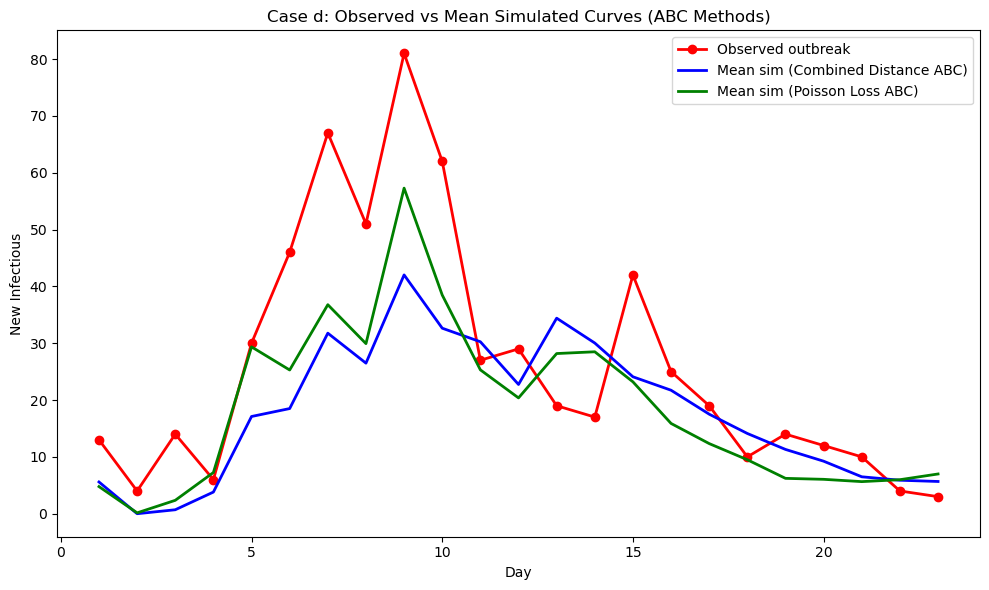

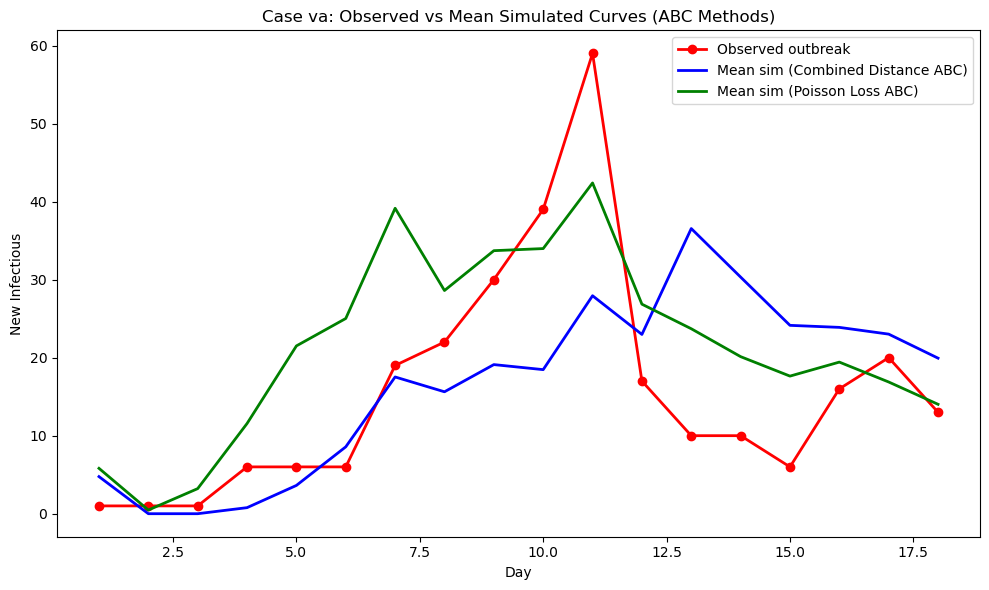

In [31]:
# # Plot comparison of mean sim curves from different ABC methods vs observed for each case
# for case in cases:
#     mean_curve_combined = mean_curves_combined[case]
#     mean_curve_plf = mean_curves_plf[case]
#     target_curve_case = target_curve[case]
#     ndays_target_case = ndays_target[case]

#     plt.figure(figsize=(10, 6))
#     days = np.arange(1, ndays_target_case + 1)

#     plt.plot(days, target_curve_case, 'o-', color='red', lw=2, label='Observed outbreak')
#     plt.plot(days, mean_curve_combined, '-', color='blue', lw=2, label='Mean sim (Combined Distance ABC)')
#     plt.plot(days, mean_curve_plf, '-', color='green', lw=2, label='Mean sim (Poisson Loss ABC)')

#     plt.xlabel("Day")
#     plt.ylabel("New Infectious")
#     plt.title(f"Case {case}: Observed vs Mean Simulated Curves (ABC Methods)")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()
#     plt.close()

In [15]:
%%time
# -------------------------
# Bayesian Optimization using gp_minimize
# -------------------------
from functools import partial
# Define the objective function to minimize (using combined distance)
def objective_combined_distance(params, burn_in_farm_case, ndays_target_case, burn_in_days, target_curve_case, no_calves):
    T, R, incubation_float, seed_float = params
    incubation = int(round(incubation_float)) # gp_minimize works with floats, convert to int
    seed = int(round(seed_float)) # gp_minimize works with floats, convert to int

    # Ensure seed is at least 1
    seed = max(1, seed)

    sim_curve = simulate_counts(
        burn_in_farm_case,
        ndays_target_case,
        burn_in_days,
        seed,
        float(T),
        float(R),
        incubation,
        pens_to_mask=no_calves
    )

    # Calculate combined distance
    d_dtw = dtw_distance(sim_curve, target_curve_case)
    d_mae = np.mean(np.abs(sim_curve - target_curve_case))
    d_cc, _ = crosscorr_alignment_distance(sim_curve, target_curve_case, max_shift=ndays_target_case//2)
    distance = d_dtw + 5.0 * d_mae + 2.0 * d_cc
    return distance

# Define the search space
space = [
    Real(T_low, T_high, name='T'),
    Real(R_low, R_high, name='R'),
    Real(INCUBATION_LOW, INCUBATION_HIGH, name='incubation'), # Treat as real for optimization
    Real(SEED_LOW, SEED_HIGH, name='initial_seed') # Treat as real for optimization
]

optimization_results_by_case = {}

for case in cases:
    print(f"\nRunning gp_minimize for case {case}...")

    # Create a partial function for the objective function, fixing the case-specific arguments
    objective_partial = partial(
        objective_combined_distance,
        burn_in_farm_case=burn_in_farms[case],
        ndays_target_case=ndays_target[case],
        burn_in_days=burn_in_days,
        target_curve_case=target_curve[case],
        no_calves=no_calves
    )

    # Run the optimization
    # Using n_calls=50 as a starting point, can be increased for better results
    # Using n_random_starts=10 to explore the space initially
    res_gp = gp_minimize(
        objective_partial,
        space,
        n_calls=100,
        n_random_starts=10,
        random_state=0, # for reproducibility
        verbose=False # to see the progress
    )

    optimization_results_by_case[case] = res_gp

#     print(f"\nOptimization results for case {case}:")
#     print("Best parameters: %s" % res_gp.x)
#     print("Best score (combined distance): %s" % res_gp.fun)

    # You can access the best parameters like this:
    best_T, best_R, best_incubation_float, best_seed_float = res_gp.x
    best_incubation = int(round(best_incubation_float))
    best_seed = int(round(best_seed_float))

    print(f"  T: {best_T:.5f}")
    print(f"  R: {best_R:.5f}")
    print(f"  Incubation: {best_incubation}")
    print(f"  Initial Seed: {best_seed}")


Running gp_minimize for case w...
  T: 0.01000
  R: 0.04000
  Incubation: 2
  Initial Seed: 2

Running gp_minimize for case t...
  T: 0.12754
  R: 0.06617
  Incubation: 5
  Initial Seed: 1

Running gp_minimize for case d...
  T: 0.01000
  R: 0.06700
  Incubation: 1
  Initial Seed: 1

Running gp_minimize for case va...
  T: 0.01000
  R: 0.04000
  Incubation: 4
  Initial Seed: 10
CPU times: user 3min 56s, sys: 50.5 s, total: 4min 47s
Wall time: 4min 34s


In [16]:
opt_raw = {}
for i, case in enumerate(cases):
    opt_raw[case] = pd.DataFrame(optimization_results_by_case[case]['x_iters'], columns = ['T', 'R', 'I', 'IC'])
    opt_raw[case]['func_vals']=optimization_results_by_case[case]['func_vals']
    opt_raw[case].to_csv(f'opt_results_dm_{i+1}.csv', index = False)

In [17]:
%%time
# -------------------------
# Bayesian Optimization using gp_minimize for poisson loss
# -------------------------

# Define the objective function to minimize (using combined distance)
def objective_combined_distance(params, burn_in_farm_case, ndays_target_case, burn_in_days, target_curve_case, no_calves):
    T, R, incubation_float, seed_float = params
    incubation = int(round(incubation_float)) # gp_minimize works with floats, convert to int
    seed = int(round(seed_float)) # gp_minimize works with floats, convert to int

    # Ensure seed is at least 1
    seed = max(1, seed)

    sim_curve = simulate_counts(
        burn_in_farm_case,
        ndays_target_case,
        burn_in_days,
        seed,
        float(T),
        float(R),
        incubation,
        pens_to_mask=no_calves
    )

    # Calculate combined distance
    distance = plf(sim_curve, target_curve_case)
    
    return distance

# Define the search space
space = [
    Real(T_low, T_high, name='T'),
    Real(R_low, R_high, name='R'),
    Real(INCUBATION_LOW, INCUBATION_HIGH, name='incubation'), # Treat as real for optimization
    Real(SEED_LOW, SEED_HIGH, name='initial_seed') # Treat as real for optimization
]

optimization_results_by_case = {}

for case in cases:
    print(f"\nRunning gp_minimize for case {case}...")

    # Create a partial function for the objective function, fixing the case-specific arguments
    objective_partial = partial(
        objective_combined_distance,
        burn_in_farm_case=burn_in_farms[case],
        ndays_target_case=ndays_target[case],
        burn_in_days=burn_in_days,
        target_curve_case=target_curve[case],
        no_calves=no_calves
    )

    # Run the optimization
    # Using n_calls=50 as a starting point, can be increased for better results
    # Using n_random_starts=10 to explore the space initially
    res_gp = gp_minimize(
        objective_partial,
        space,
        n_calls=100,
        n_random_starts=10,
        random_state=0, # for reproducibility
        verbose=False # to see the progress
    )

    optimization_results_by_case[case] = res_gp

#     print(f"\nOptimization results for case {case}:")
#     print("best_plf parameters: %s" % res_gp.x)
#     print("best_plf score (combined distance): %s" % res_gp.fun)

    # You can access the best_plf parameters like this:
    best_plf_T, best_plf_R, best_plf_incubation_float, best_plf_seed_float = res_gp.x
    best_plf_incubation = int(round(best_plf_incubation_float))
    best_plf_seed = int(round(best_plf_seed_float))

    print(f"  T: {best_plf_T:.5f}")
    print(f"  R: {best_plf_R:.5f}")
    print(f"  Incubation: {best_plf_incubation}")
    print(f"  Initial Seed: {best_plf_seed}")


Running gp_minimize for case w...
  T: 0.01000
  R: 0.04000
  Incubation: 6
  Initial Seed: 7

Running gp_minimize for case t...
  T: 0.01000
  R: 0.04032
  Incubation: 1
  Initial Seed: 8

Running gp_minimize for case d...
  T: 0.01000
  R: 0.08000
  Incubation: 2
  Initial Seed: 2

Running gp_minimize for case va...
  T: 0.01000
  R: 0.04000
  Incubation: 2
  Initial Seed: 1
CPU times: user 4min 3s, sys: 33.6 s, total: 4min 37s
Wall time: 4min 15s


In [18]:
opt_raw = {}
for i, case in enumerate(cases):
    opt_raw[case] = pd.DataFrame(optimization_results_by_case[case]['x_iters'], columns = ['T', 'R', 'I', 'IC'])
    opt_raw[case]['func_vals']=optimization_results_by_case[case]['func_vals']
    opt_raw[case].to_csv(f'opt_results_plf_{i+1}.csv', index = False)

In [36]:
# ########### simulating optimal rates ######

# N_post_sims = 200  # number of posterior simulations to run

# # Dictionary to store mean curves for PLF
# mean_curves_optimal1 = {}
# mean_curves_optimal2 = {}

# for case in cases:
#     print(f"\nRunning posterior simulations with optimal params for case {case}...")
#     ndays_target_case = ndays_target[case]
#     burn_in_farm_case = burn_in_farms[case]
#     target_curve_case = target_curve[case]

#     all_post_optimal1 = []
#     all_post_optimal2 = []
    
#     for n in range(N_post_sims):
#         sim_curve1 = simulate_counts(burn_in_farm_case, ndays_target_case, burn_in_days,
#                                     best_seed, best_T, best_R,
#                                     best_incubation, no_calves)
#         all_post_optimal1.append(sim_curve1)
#         sim_curve2 = simulate_counts(burn_in_farm_case, ndays_target_case, burn_in_days,
#                                     best_plf_seed, best_plf_T, best_plf_R,
#                                     best_plf_incubation, no_calves)
#         all_post_optimal2.append(sim_curve2)
        
#     all_post_optimal1 = np.array(all_post_optimal1)
#     all_post_optimal2 = np.array(all_post_optimal2)

#     # Compute posterior predictive mean and 90% confidence interval
#     mean_curve_optimal1 = np.mean(all_post_optimal1, axis=0)
# #     low_curve_optimal1 = np.percentile(all_post_optimal1, 5, axis=0)
# #     high_curve_optimal1 = np.percentile(all_post_optimal1, 95, axis=0)
    
#     mean_curve_optimal2 = np.mean(all_post_optimal2, axis=0)
# #     low_curve_optimal2 = np.percentile(all_post_optimal2, 5, axis=0)
# #     high_curve_optimal2 = np.percentile(all_post_optimal2, 95, axis=0)

#     mean_curves_optimal1[case] = mean_curve_optimal1
#     mean_curves_optimal2[case] = mean_curve_optimal2
    
#     # -------------------------
#     # Plot observed vs posterior predictive distribution (mean with 90% CI)
#     # -------------------------
#     mean_curve_combined = mean_curves_optimal1[case]
#     mean_curve_plf = mean_curves_optimal2[case]

#     plt.figure(figsize=(10, 6))
#     days = np.arange(1, ndays_target_case + 1)

#     plt.plot(days, target_curve_case, 'o-', color='red', lw=2, label='Observed outbreak')
#     plt.plot(days, mean_curve_combined, '-', color='blue', lw=2, label='Optimal sim (Combined Distance ABC)')
#     plt.plot(days, mean_curve_plf, '-', color='green', lw=2, label='Optimal sim (Poisson Loss ABC)')

#     plt.xlabel("Day")
#     plt.ylabel("New Infectious")
#     plt.title(f"Farm {case}: Observed vs Optimal Simulated Curves using gp_minimize()")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()
#     plt.close()


Running posterior simulations with optimal params for case w...


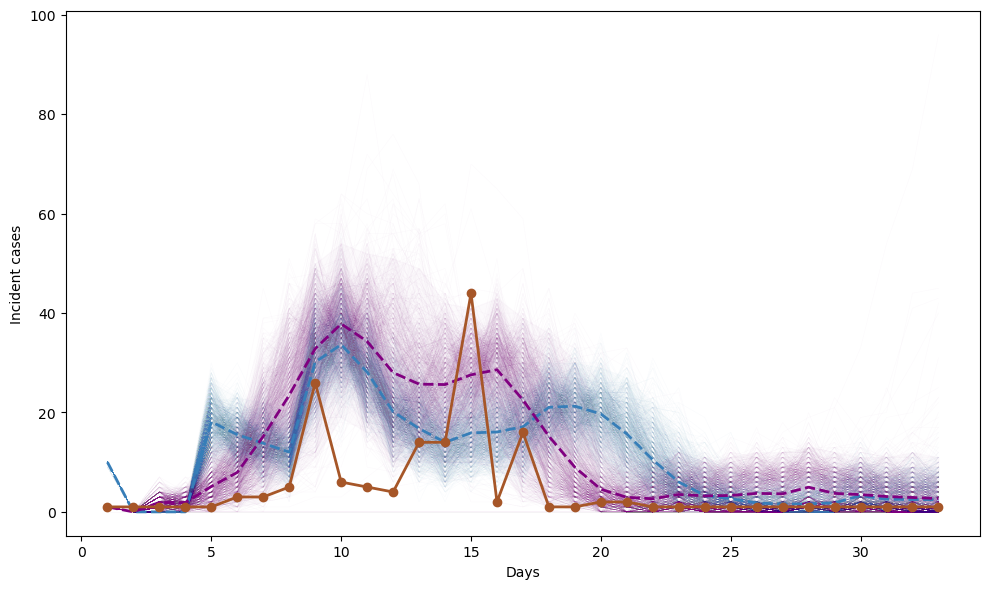


Running posterior simulations with optimal params for case t...


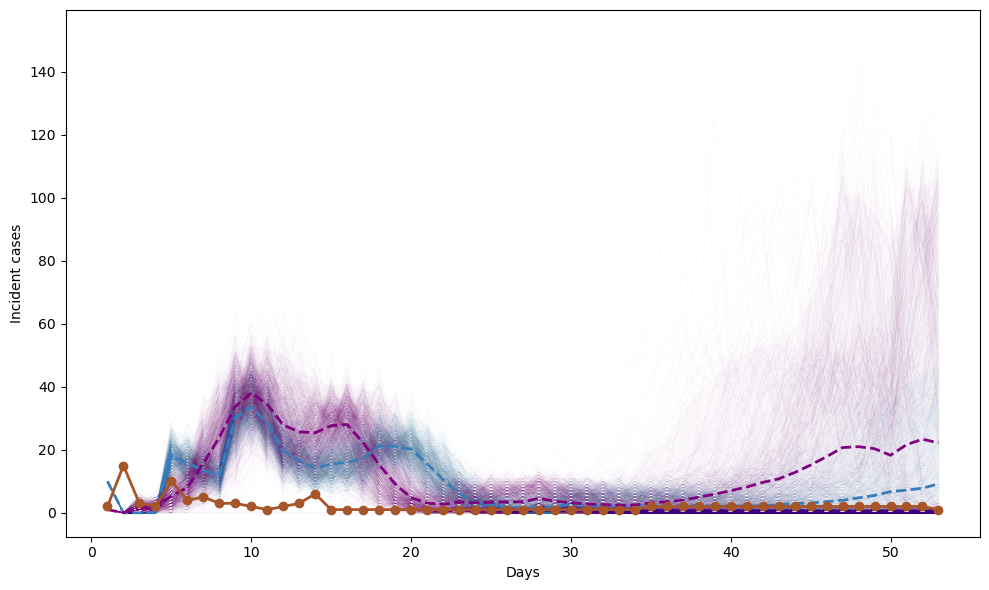


Running posterior simulations with optimal params for case d...


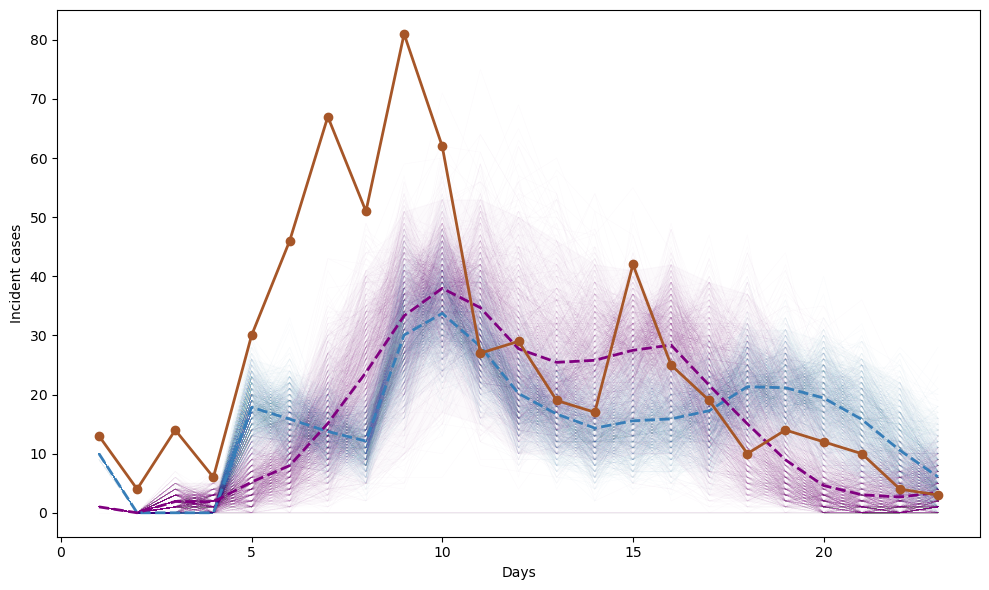


Running posterior simulations with optimal params for case va...


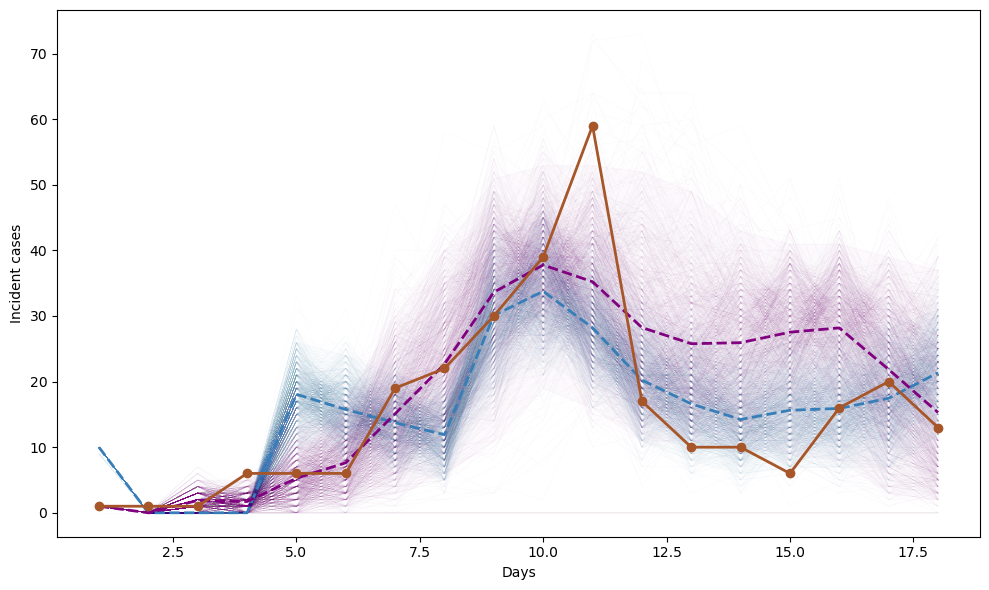

In [42]:
########### simulating optimal rates ######

N_post_sims = 1000  # number of posterior simulations to run

# Dictionary to store mean curves for PLF
mean_curves_optimal1 = {}
mean_curves_optimal2 = {}

for case in cases:
    print(f"\nRunning posterior simulations with optimal params for case {case}...")
    ndays_target_case = ndays_target[case]
    burn_in_farm_case = burn_in_farms[case]
    target_curve_case = target_curve[case]

    all_post_optimal1 = []
    all_post_optimal2 = []
    
    for n in range(N_post_sims):
        sim_curve1 = simulate_counts(
            burn_in_farm_case, ndays_target_case, burn_in_days,
            best_seed, best_T, best_R,
            best_incubation, no_calves
        )
        all_post_optimal1.append(sim_curve1)

        sim_curve2 = simulate_counts(
            burn_in_farm_case, ndays_target_case, burn_in_days,
            best_plf_seed, best_plf_T, best_plf_R,
            best_plf_incubation, no_calves
        )
        all_post_optimal2.append(sim_curve2)
        
    all_post_optimal1 = np.array(all_post_optimal1)
    all_post_optimal2 = np.array(all_post_optimal2)

    # Compute posterior predictive mean and 95% credible interval
    mean_curve_optimal1 = np.mean(all_post_optimal1, axis=0)
    low_curve_optimal1  = np.percentile(all_post_optimal1, 2.5, axis=0)
    high_curve_optimal1 = np.percentile(all_post_optimal1, 97.5, axis=0)

    mean_curve_optimal2 = np.mean(all_post_optimal2, axis=0)
    low_curve_optimal2  = np.percentile(all_post_optimal2, 2.5, axis=0)
    high_curve_optimal2 = np.percentile(all_post_optimal2, 97.5, axis=0)

    mean_curves_optimal1[case] = mean_curve_optimal1
    mean_curves_optimal2[case] = mean_curve_optimal2
    
    # -------------------------
    # Plot observed vs posterior predictive distribution
    #  - all posterior curves faded
    #  - mean with 95% CI band
    # -------------------------
    plt.figure(figsize=(10, 6))
    days = np.arange(1, ndays_target_case + 1)

    for sim in all_post_optimal1:
        plt.plot(days, sim, color='#377eb8', alpha=0.02, linewidth=0.5)
    for sim in all_post_optimal2:
        plt.plot(days, sim, color='purple', alpha=0.02, linewidth=0.5)

    # 2) 95% CI bands around mean curves
    plt.fill_between(
        days, low_curve_optimal1, high_curve_optimal1,
        color='#377eb8', alpha=0.02
    )
    plt.fill_between(
        days, low_curve_optimal2, high_curve_optimal2,
        color='purple', alpha=0.02
    )

    # 3) Observed and mean curves on top

    plt.plot(
        days, mean_curve_optimal1, '--', color='#377eb8', lw=2,
        label='Median Curve - Optimal sim (Combined Distance BA)'
    )
    plt.plot(
        days, mean_curve_optimal2, '--', color='purple', lw=2,
        label='Median Curve - Optimal sim (Poisson Loss BA)'
    )
    plt.plot(
        days, target_curve_case, 'o-', color='#a65628', lw=2,
        label='Observed outbreak'
    )

    plt.xlabel("Days")
    plt.ylabel("Incident cases")
#     plt.title(f"Farm {case}: Observed vs Optimal Simulated Curves using gp_minimize()")
#     plt.legend(loc = 'upper left')
    plt.tight_layout()
    plt.savefig(f"optimal_curves_{case}.png", transparent = True, format = "png", dpi = 300)
    plt.show()
    plt.close()


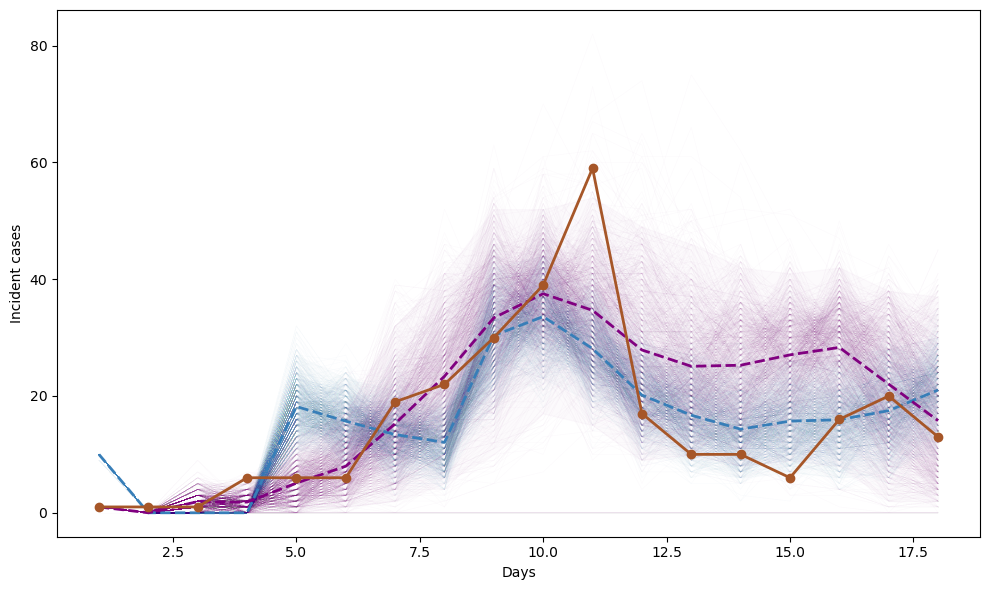

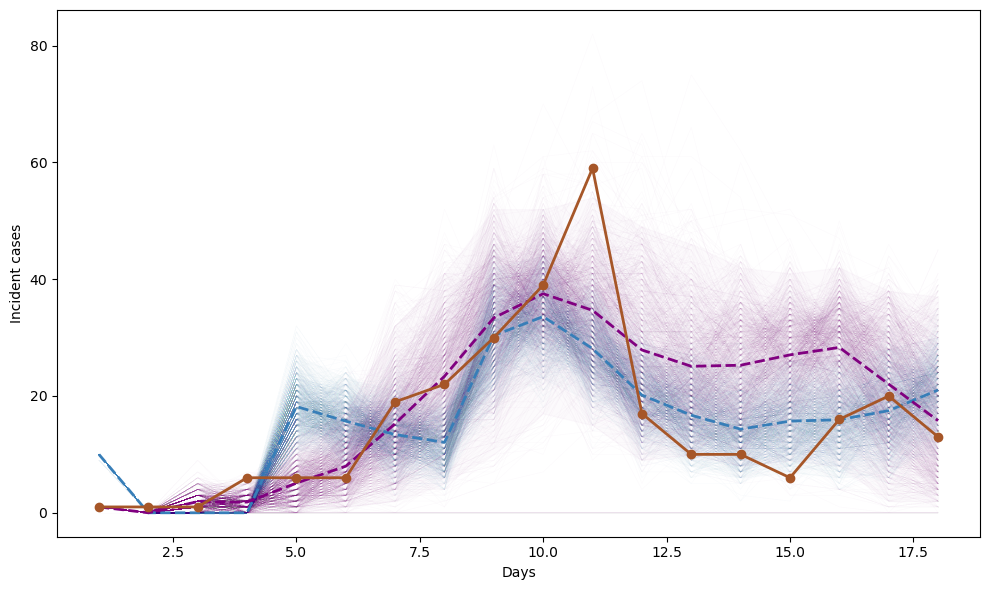

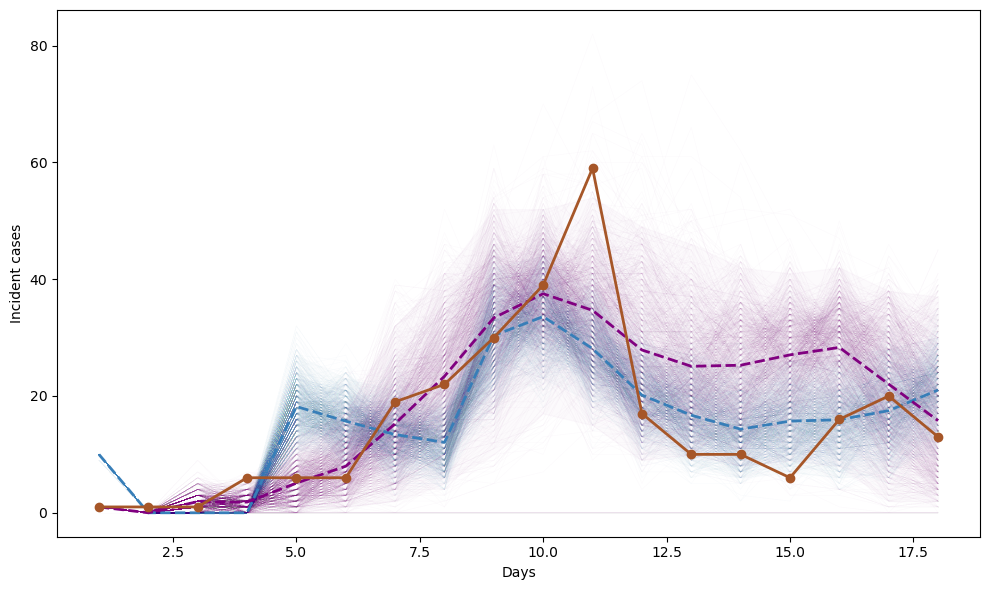

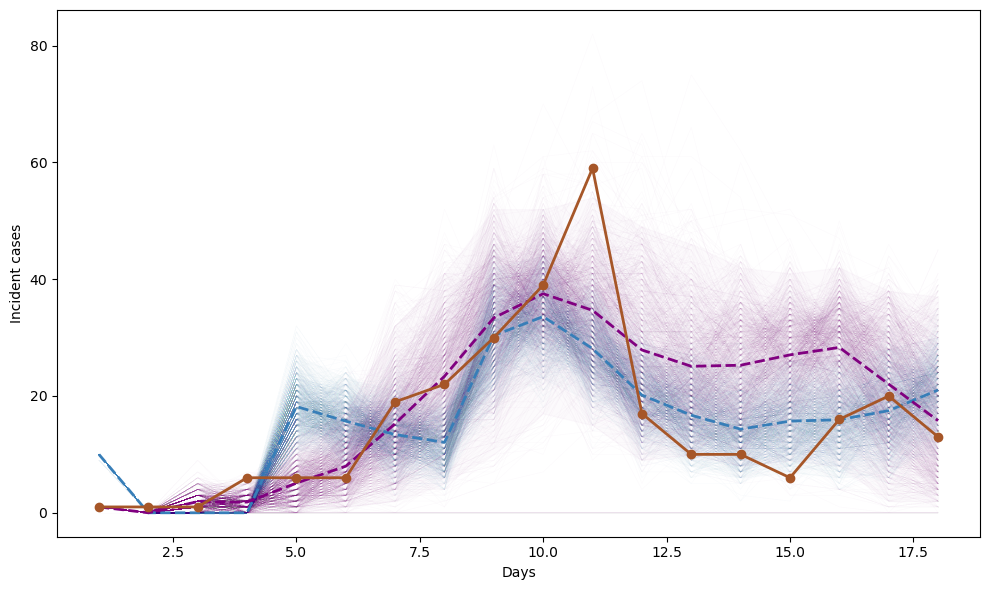

In [41]:
for sim in all_post_optimal1:
    plt.plot(days, sim, color='#377eb8', alpha=0.02, linewidth=0.5)
for sim in all_post_optimal2:
    plt.plot(days, sim, color='purple', alpha=0.02, linewidth=0.5)

    # 2) 95% CI bands around mean curves
plt.fill_between(
        days, low_curve_optimal1, high_curve_optimal1,
        color='#377eb8', alpha=0.02
    )
plt.fill_between(
        days, low_curve_optimal2, high_curve_optimal2,
        color='purple', alpha=0.02
    )

    # 3) Observed and mean curves on top

plt.plot(
        days, mean_curve_optimal1, '--', color='#377eb8', lw=2,
        label='Median Curve - Optimal sim (Combined Distance BA)'
    )
plt.plot(
        days, mean_curve_optimal2, '--', color='purple', lw=2,
        label='Median Curve - Optimal sim (Poisson Loss BA)'
    )
plt.plot(
        days, target_curve_case, 'o-', color='#a65628', lw=2,
        label='Observed outbreak'
    )

plt.xlabel("Days")
plt.ylabel("Incident cases")
#     plt.title(f"Farm {case}: Observed vs Optimal Simulated Curves using gp_minimize()")
#     plt.legend(loc = 'upper left')
plt.tight_layout()
plt.savefig(f"optimal_curves_{case}.png", transparent = True, format = "png", dpi = 300)
plt.show()
plt.close()

In [38]:
# import os

# # Define output directory
# OUT_DIR = "./grid_search_results"
# os.makedirs(OUT_DIR, exist_ok=True)

# # define grid axes (pick small sizes if needed)
# grid_T = np.linspace(0.01, 0.15, 25) # reduce if slow
# grid_R = np.linspace(0.04, 0.08, 25)
# grid_inc = np.arange(INCUBATION_LOW, INCUBATION_HIGH + 1, max(1, (INCUBATION_HIGH - INCUBATION_LOW)//2 or 1))
# grid_seed = np.arange(SEED_LOW, SEED_HIGH + 1)

# grid_results_by_case = {}

# for case in cases:
#     print(f"\nRunning grid search for case {case}...")
#     burn_in_farm_case = burn_in_farms[case]
#     ndays_target_case = ndays_target[case]
#     target_curve_case = target_curve[case]

#     grid_results = []
#     for T in tqdm(grid_T, desc=f"Grid Search (T) for {case}"):
#         for R in grid_R:
#             for incubation in grid_inc:
#                 for seed in grid_seed:
#                     sim_curve = simulate_counts(
#                         burn_in_farm_case,
#                         ndays_target_case,
#                         burn_in_days,
#                         seed,
#                         float(T),
#                         float(R),
#                         int(incubation),
#                         pens_to_mask=no_calves
#                     )
#                     d_dtw = dtw_distance(sim_curve, target_curve_case)
#                     d_mae = np.mean(np.abs(sim_curve - target_curve_case))
#                     d_cc, best_shift = crosscorr_alignment_distance(sim_curve, target_curve_case, max_shift=ndays_target_case//2)
#                     plf_apply = plf(sim_curve, target_curve_case)  # Calculate Poisson Loss Function
#                     grid_results.append({
#                         'T': T,
#                         'R': R,
#                         'incubation': int(incubation),
#                         'initial_seed': int(seed),
#                         'dtw': d_dtw,
#                         'mae': d_mae,
#                         'cc_mae': d_cc,
#                         'poisson_loss': plf_apply,  # Add Poisson Loss
#                         'best_shift': best_shift,
#                         'sim_curve': sim_curve
#                     })
#     grid_results_by_case[case] = grid_results
#     grid_df = pd.DataFrame(grid_results)
#     grid_df.to_pickle(os.path.join(OUT_DIR, f"grid_results_{case}.pkl"))
#     print(f"Grid search finished for case {case}. Results saved to grid_results_{case}.pkl")

In [39]:
# # Display grid search results for each case
# for case in cases:
#     print(f"\nGrid search results for case {case}:")
#     grid_df = grid_results_by_case[case]

#     # find best by different metrics
#     # Function to find dictionary with minimum value for a given key
#     def get_best_dict(data_list, key):
#         try:
#             return min(data_list, key=lambda x: x[key])
#         except (KeyError, TypeError) as e:
#             print(f"Error for key '{key}' in case {case}: {e}")
#             return None

#     # Find best by different metrics
#     best_dtw = get_best_dict(grid_df, 'dtw')
#     best_mae = get_best_dict(grid_df, 'mae')
#     best_cc = get_best_dict(grid_df, 'cc_mae')
#     best_plf = get_best_dict(grid_df, 'poisson_loss')


#     print("\nGrid search bests:")
#     print(" Best DTW:    T={T:.5f}, R={R:.5f}, incubation={incubation}, seed={initial_seed}, dtw={dtw:.3f}".format(**best_dtw))
#     print(" Best MAE:    T={T:.5f}, R={R:.5f}, incubation={incubation}, seed={initial_seed}, mae={mae:.3f}".format(**best_mae))
#     print(" Best cross-corr aligned MAE: T={T:.5f}, R={R:.5f}, cc_mae={cc_mae:.3f}, shift={best_shift}".format(**best_cc))
#     print(" Best Poisson Loss: T={T:.5f}, R={R:.5f}, incubation={incubation}, seed={initial_seed}, poisson_loss={poisson_loss:.3f}".format(**best_plf))

In [40]:
# for case in cases:
#     print(f"\nPlotting grid search best fits for case {case}:")
#     grid_df = pd.DataFrame(grid_results_by_case[case])
#     target_curve_case = target_curve[case]
#     ndays_target_case = ndays_target[case]

#     best_dtw = grid_df.loc[grid_df['dtw'].idxmin()]
#     best_mae = grid_df.loc[grid_df['mae'].idxmin()]
#     best_cc = grid_df.loc[grid_df['cc_mae'].idxmin()]
#     best_plf = grid_df.loc[grid_df['poisson_loss'].idxmin()]

#     plt.figure(figsize=(10, 6))
#     days = np.arange(1, ndays_target_case + 1)

#     plt.plot(days, target_curve_case, 'o-', color='red', lw=2, label='Observed outbreak')
#     plt.plot(days, best_dtw['sim_curve'][:ndays_target_case], 's--', color='blue', 
#              label=f"Best DTW (T={best_dtw['T']:.4f},R={best_dtw['R']:.4f})", alpha = 0.5)
#     plt.plot(days, best_mae['sim_curve'][:ndays_target_case], 'x--', color='green', 
#              label=f"Best MAE (T={best_mae['T']:.4f},R={best_mae['R']:.4f})", alpha = 0.5)

#     sim_cc = best_cc['sim_curve']
#     shift = int(best_cc.get('best_shift', 0))
#     if shift > 0:
#         sim_cc_plot = np.concatenate([np.zeros(shift, dtype=int), sim_cc])[:ndays_target_case]
#     elif shift < 0:
#         sim_cc_plot = np.concatenate([sim_cc[-shift:], np.zeros(ndays_target_case - len(sim_cc[-shift:]), dtype=int)])[:ndays_target_case]
#     else:
#         sim_cc_plot = sim_cc[:ndays_target_case]
#     plt.plot(days, sim_cc_plot, 'd--', color='purple', 
#              label=f"Best CC-align (T={best_cc['T']:.4f},R={best_cc['R']:.4f},shift={shift})",
#              alpha = 0.5)

#     plt.plot(days, best_plf['sim_curve'][:ndays_target_case], '*--', 
#              color='orange', label=f"Best PLF (T={best_plf['T']:.4f},R={best_plf['R']:.4f})", 
#              alpha = 0.5)

#     plt.xlabel("Day")
#     plt.ylabel("New Infectious")
#     plt.title(f"Case {case}: Observed vs Best Grid-fit Simulations")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()
#     plt.close()